# Time Series Classification — Full Optimised Pipeline

**Dataset:** CMI wrist actigraphy · 3 355 train / 953 test · 200 timesteps · 7 channels · Binary (sii)

**Methods from teacher's lab (03 + 04):**
- `ShapeletTransformClassifier` end-to-end pipeline
- `RandomShapeletTransform` + **DecisionTree** (teacher's interpretation method → shows which shapelet is the root split)
- `RandomShapeletTransform` + **LogisticRegression** (teacher's linear variant)
- `RDSTClassifier` from `aeon` (teacher's dilated shapelet method — fastest)
- Shapelet visualisation: plot shapelet overlaid on test instance (teacher Cell 102 pattern)

**Performance improvements applied:**
- Channel selection via Mann-Whitney U (reduces 7 → 3 best channels)
- Window length guided by motif analysis (min=30, max=100)
- All data cast to float64 (fixes numba type errors in RDST/DrCIF)

## Cell 1 — Installs

In [1]:
# Cell 1 – use Colab's default versions
import numpy as np
import pandas as pd

print("NumPy version:", np.__version__)   # Expect ~2.0.2
print("Pandas version:", pd.__version__)  # Expect ~2.2.2
print("Cell 1 successful!")

NumPy version: 2.0.2
Pandas version: 2.2.2
Cell 1 successful!


## Cell 2 — Imports

In [2]:
!pip install sktime aeon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 11.9 MB/s eta 0:00:00


In [3]:
import random, warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy.stats import mannwhitneyu
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import RidgeClassifierCV, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                              classification_report, confusion_matrix, roc_auc_score,
                              RocCurveDisplay)
from imblearn.over_sampling import RandomOverSampler

from sktime.transformations.panel.shapelet_transform import RandomShapeletTransform
from sktime.classification.shapelet_based import ShapeletTransformClassifier
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from aeon.classification.shapelet_based import RDSTClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

SEED = 42
random.seed(SEED); np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 110
print("All imports OK")

All imports OK


## Cell 3 — Load Data

In [4]:
DATA_DIR = "."

X_train = np.load(f"{DATA_DIR}/X_train_raw.npy")
X_test  = np.load(f"{DATA_DIR}/X_test_raw.npy")
y_train = np.load(f"{DATA_DIR}/y_train.npy").astype(int)
y_test  = np.load(f"{DATA_DIR}/y_test.npy").astype(int)

N_TRAIN, T, C = X_train.shape
N_TEST = X_test.shape[0]
print(f"Train : {X_train.shape}  |  Test: {X_test.shape}")
print(f"Classes train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Imbalance    : {np.bincount(y_train)[0]/np.bincount(y_train)[1]:.2f}:1")

Train : (3355, 200, 7)  |  Test: (953, 200, 7)
Classes train: {np.int64(0): np.int64(2192), np.int64(1): np.int64(1163)}
Imbalance    : 1.88:1


## Cell 4 — Pre-processing

Two key decisions from teacher's lab applied here:
1. **float64 throughout** — required by `aeon` (RDST uses numba and fails on float32)
2. **Channel selection** — Mann-Whitney U per channel; only statistically significant channels fed to shapelet methods

Discriminative channels (p<0.05): [0, 3, 5]  (3/7)


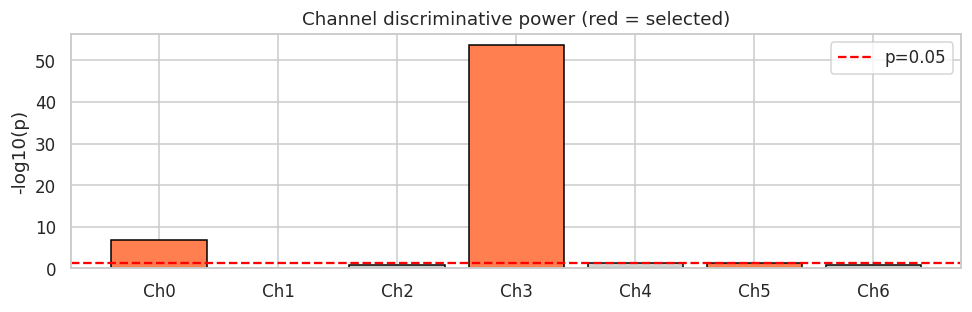

Full feat tensor   : (3355, 200, 14)
sktime sel input   : (3355, 3, 200)
Flat KNN input     : (3355, 2800)


In [5]:
# ── Z-normalise (float64 for aeon/numba compatibility) ────────────────────
Xtr_z = np.zeros_like(X_train, dtype=np.float64)
Xte_z = np.zeros_like(X_test,  dtype=np.float64)
for ch in range(C):
    sc = StandardScaler()
    Xtr_z[:, :, ch] = sc.fit_transform(X_train[:, :, ch])
    Xte_z[:, :, ch] = sc.transform(X_test[:, :, ch])

# ── Add first-derivative channels ─────────────────────────────────────────
def add_deriv(X):
    dX = np.diff(X, axis=1, prepend=X[:, :1, :])
    return np.concatenate([X, dX], axis=2)

Xtr_feat = add_deriv(Xtr_z)   # (N, T, 14)
Xte_feat = add_deriv(Xte_z)

# ── Channel selection (Mann-Whitney U on raw 7 channels) ──────────────────
pvals = []
for ch in range(C):
    _, p = mannwhitneyu(Xtr_z[y_train==0, :, ch].mean(1),
                        Xtr_z[y_train==1, :, ch].mean(1),
                        alternative='two-sided')
    pvals.append(p)

BEST_CH = sorted([ch for ch, p in enumerate(pvals) if p < 0.05])
print(f"Discriminative channels (p<0.05): {BEST_CH}  ({len(BEST_CH)}/{C})")

# Bar chart of channel significance
fig, ax = plt.subplots(figsize=(9, 3))
colors_ch = ['coral' if p < 0.05 else 'lightgray' for p in pvals]
ax.bar(range(C), [-np.log10(p+1e-300) for p in pvals], color=colors_ch, edgecolor='k')
ax.axhline(-np.log10(0.05), color='red', ls='--', lw=1.5, label='p=0.05')
ax.set_xticks(range(C))
ax.set_xticklabels([f'Ch{i}' for i in range(C)])
ax.set_ylabel('-log10(p)'); ax.set_title('Channel discriminative power (red = selected)')
ax.legend(); plt.tight_layout(); plt.show()

# ── Prepared inputs (sktime expects (N, C, T), aeon same) ─────────────────
Xtr_sk_all  = np.transpose(Xtr_z,                    (0, 2, 1))  # all 7ch, T
Xte_sk_all  = np.transpose(Xte_z,                    (0, 2, 1))
Xtr_sk_sel  = np.transpose(Xtr_z[:, :, BEST_CH],     (0, 2, 1))  # best ch only
Xte_sk_sel  = np.transpose(Xte_z[:, :, BEST_CH],     (0, 2, 1))
Xtr_sk_feat = np.transpose(Xtr_feat[:, :, BEST_CH],  (0, 2, 1))  # best + deriv
Xte_sk_feat = np.transpose(Xte_feat[:, :, BEST_CH],  (0, 2, 1))

# Flat for KNN
Xtr_flat = Xtr_feat.reshape(N_TRAIN, -1).astype(np.float64)
Xte_flat = Xte_feat.reshape(N_TEST,  -1).astype(np.float64)

print(f"Full feat tensor   : {Xtr_feat.shape}")
print(f"sktime sel input   : {Xtr_sk_sel.shape}")
print(f"Flat KNN input     : {Xtr_flat.shape}")

## Cell 5 — Evaluation Helper

In [6]:
RESULTS = []

def evaluate_model(name, y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else float("nan")

    print("=" * 58)
    print(f"  {name}")
    print("=" * 58)
    print(f"  Accuracy          {acc:.4f}")
    print(f"  Balanced Accuracy {bal:.4f}")
    print(f"  Macro F1          {f1:.4f}")
    if not np.isnan(auc): print(f"  ROC-AUC           {auc:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["Class 0","Class 1"]))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(3.5, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"])
    plt.title(name, fontsize=9); plt.tight_layout(); plt.show()

    RESULTS.append({"Model": name, "Macro F1": f1, "Bal Acc": bal, "ROC-AUC": auc})

print("evaluate_model() ready")

evaluate_model() ready


---
# Section B — Shapelet Methods

**Teacher methods applied:**
1. `RandomShapeletTransform` + `DecisionTree` — teacher's interpretation approach: the tree shows exactly which shapelet is the most discriminative root split
2. `RandomShapeletTransform` + `LogisticRegression` — teacher's linear variant
3. `RandomShapeletTransform` + `XGBoost` — strongest non-linear head
4. `RDSTClassifier` (aeon) — teacher's dilated shapelet method, 10–100× faster than RST
5. `ShapeletTransformClassifier` — teacher's end-to-end pipeline



## Cell 9 — RandomShapeletTransform (channel-filtered)

In [7]:
# Using only the statistically discriminative channels
# min_shapelet_length=30 guided by motif analysis (top shapelets at pos 90-150)
rst = RandomShapeletTransform(
    n_shapelet_samples  = 500,
    max_shapelets       = 20,
    min_shapelet_length = 30,
    max_shapelet_length = 100,
    random_state        = SEED,
    n_jobs              = -1
)
print(f"Fitting RST on {Xtr_sk_sel.shape} — expect ~25 min on Colab ...")
t0 = time.time()
Xtr_shape = rst.fit_transform(Xtr_sk_sel, y_train)
Xte_shape = rst.transform(Xte_sk_sel)
print(f"Done in {time.time()-t0:.0f}s  |  features: {Xtr_shape.shape}")

shapelets = rst.shapelets
qs = sorted([sh[0] for sh in shapelets], reverse=True)
print(f"Top-5 IG scores: {[round(q, 5) for q in qs[:5]]}")

Fitting RST on (3355, 3, 200) — expect ~25 min on Colab ...
Done in 2281s  |  features: (3355, 20)
Top-5 IG scores: [0.01357, 0.01334, 0.01312, 0.01205, 0.01171]


## Cell 10 — Shapelet Analysis

Tuple layout in sktime 0.29: `(quality, length, start_pos, channel, inst_idx, cls_idx, values_array)`

Total shapelets: 20

Top 10 by information gain:
 rank  quality  length  start  channel_in  orig_ch  class
    1  0.01357      73     30           1        3      0
    2  0.01334      93     14           1        3      0
    3  0.01312      98      6           1        3      0
    4  0.01205      94     35           1        3      0
    5  0.01171      73    125           1        3      1
    6  0.01127      90     71           1        3      1
    7  0.01110      67     72           1        3      1
    8  0.01044      79    115           1        3      0
    9  0.01018      88     74           1        3      0
   10  0.00972      81     60           1        3      0


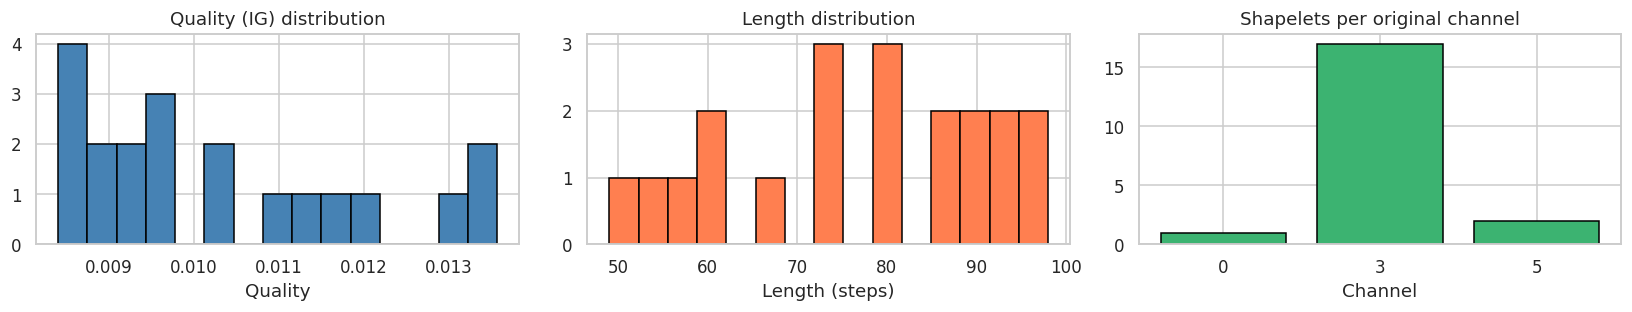

In [8]:
rows = [{"rank": i+1, "quality": round(float(sh[0]),5), "length": int(sh[1]),
          "start": int(sh[2]), "channel_in": int(sh[3]),
          "orig_ch": BEST_CH[int(sh[3])] if int(sh[3]) < len(BEST_CH) else int(sh[3]),
          "class": int(sh[5])}
        for i, sh in enumerate(shapelets)]

df_sh = pd.DataFrame(rows)
print(f"Total shapelets: {len(shapelets)}")
print("\nTop 10 by information gain:")
print(df_sh.sort_values("quality", ascending=False).head(10).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
axes[0].hist(df_sh["quality"], bins=15, color="steelblue", edgecolor="k")
axes[0].set_title("Quality (IG) distribution"); axes[0].set_xlabel("Quality")

axes[1].hist(df_sh["length"], bins=15, color="coral", edgecolor="k")
axes[1].set_title("Length distribution"); axes[1].set_xlabel("Length (steps)")

ch_counts = df_sh["orig_ch"].value_counts().sort_index()
axes[2].bar(ch_counts.index.astype(str), ch_counts.values, color="mediumseagreen", edgecolor="k")
axes[2].set_title("Shapelets per original channel"); axes[2].set_xlabel("Channel")

plt.tight_layout(); plt.show()

## Cell 11 — Top 4 Shapelets by Information Gain (shape + distance distributions)

Top 4 shapelets:
Rank             IG   Length   Orig Ch    Start
----------------------------------------------
  1         0.01357       73         3       30
  2         0.01334       93         3       14
  3         0.01312       98         3        6
  4         0.01205       94         3       35


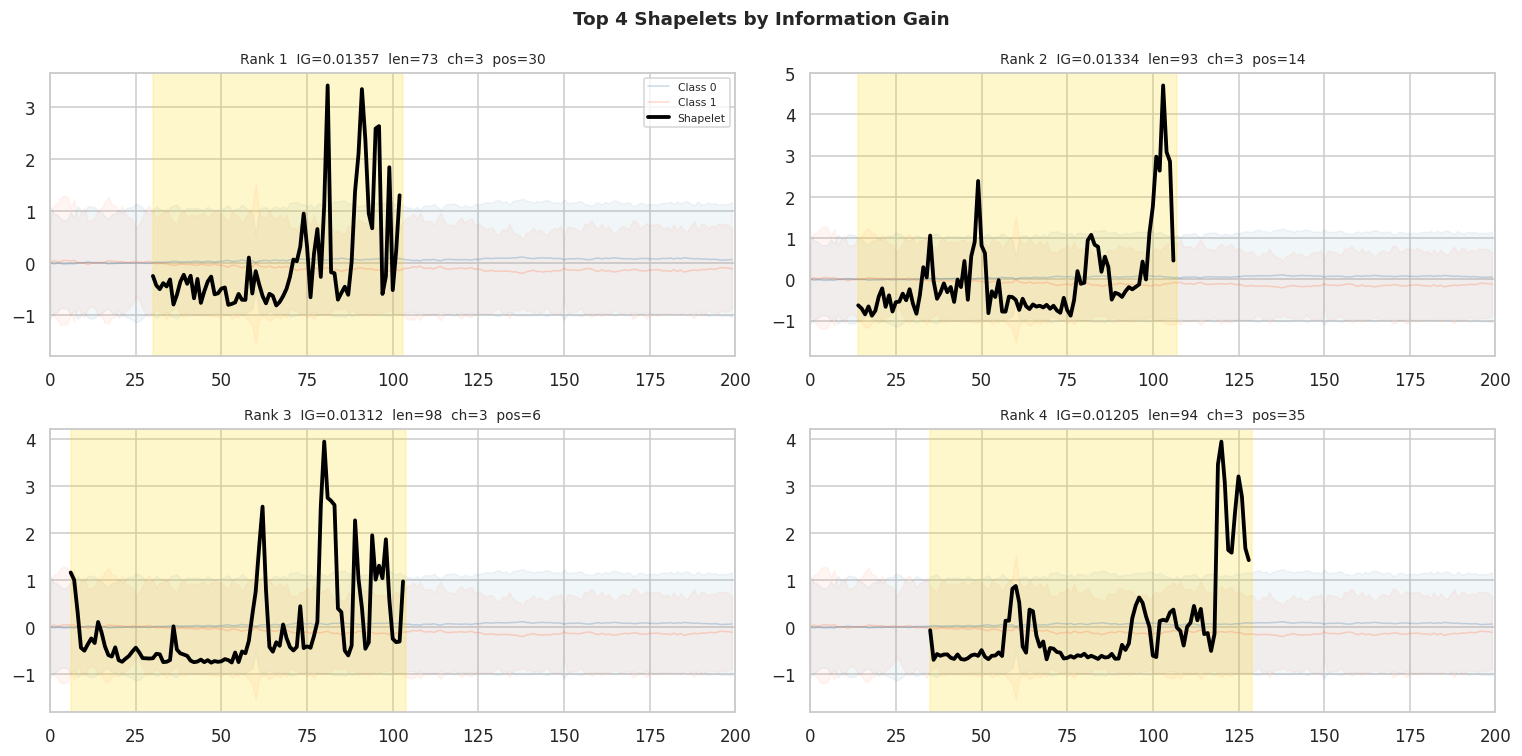

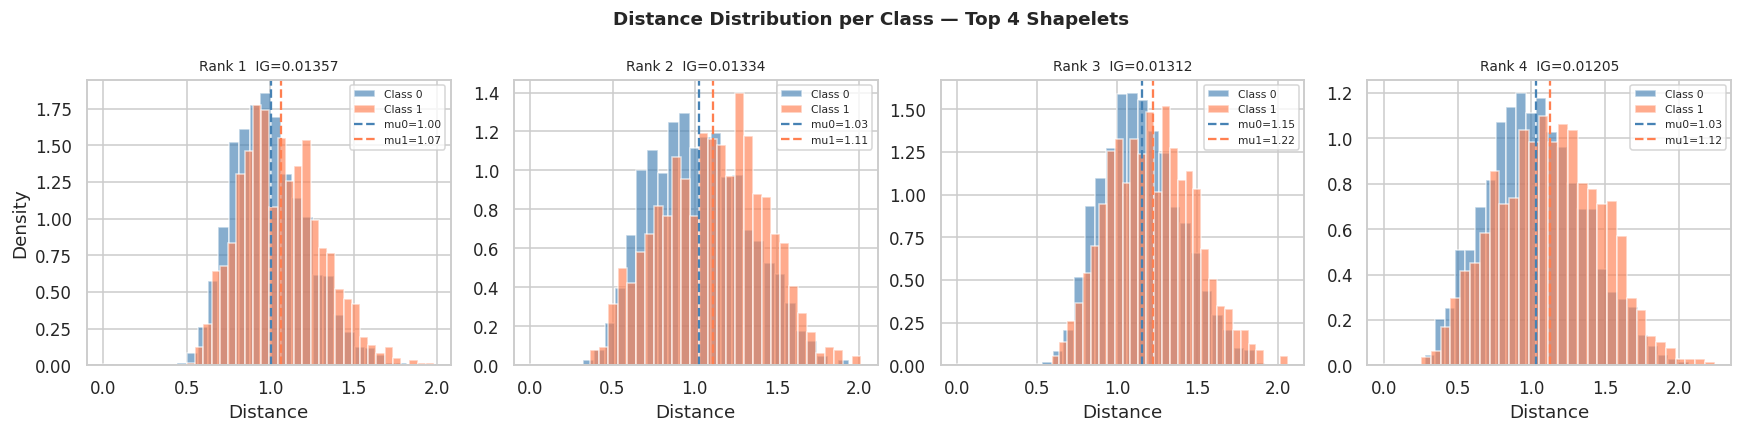

In [9]:
sorted_sh = sorted(shapelets, key=lambda s: s[0], reverse=True)
top4 = sorted_sh[:4]

print("Top 4 shapelets:")
print(f"{'Rank':<6} {'IG':>12} {'Length':>8} {'Orig Ch':>9} {'Start':>8}")
print("-" * 46)
for i, sh in enumerate(top4):
    orig = BEST_CH[int(sh[3])] if int(sh[3]) < len(BEST_CH) else int(sh[3])
    print(f"  {i+1:<4} {float(sh[0]):>12.5f} {int(sh[1]):>8} {orig:>9} {int(sh[2]):>8}")

# Figure 1: Shapes on class-mean background
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.flatten()
for idx, (ax, sh) in enumerate(zip(axes, top4)):
    quality = float(sh[0]); length = int(sh[1])
    pos     = int(sh[2]);   ch_in  = int(sh[3])
    sv      = np.array(sh[6]).flatten()
    orig_ch = BEST_CH[ch_in] if ch_in < len(BEST_CH) else ch_in

    for cls, colour in zip([0, 1], ['steelblue', 'coral']):
        mask = y_train == cls
        mu   = Xtr_z[mask, :, orig_ch].mean(0)
        sig  = Xtr_z[mask, :, orig_ch].std(0)
        ax.plot(mu, color=colour, alpha=0.3, lw=1, label=f'Class {cls}')
        ax.fill_between(np.arange(T), mu-sig, mu+sig, color=colour, alpha=0.07)

    t_sh = np.arange(pos, pos + len(sv))
    ax.plot(t_sh, sv, color='black', lw=2.5, zorder=5, label='Shapelet')
    ax.axvspan(pos, pos + len(sv), color='gold', alpha=0.2)
    ax.set_title(f"Rank {idx+1}  IG={quality:.5f}  len={length}  ch={orig_ch}  pos={pos}", fontsize=9)
    ax.set_xlim(0, T)
    if idx == 0: ax.legend(fontsize=7)

fig.suptitle('Top 4 Shapelets by Information Gain', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Figure 2: Distance distributions per class
feat_arr = np.array(Xtr_shape)
all_q    = [sh[0] for sh in shapelets]
top4_col = sorted(range(len(all_q)), key=lambda i: all_q[i], reverse=True)[:4]

fig2, axes2 = plt.subplots(1, 4, figsize=(16, 4))
for idx, (ax, col_i) in enumerate(zip(axes2, top4_col)):
    sh = shapelets[col_i]
    d0 = feat_arr[y_train==0, col_i]; d1 = feat_arr[y_train==1, col_i]
    ax.hist(d0, bins=30, alpha=0.65, color='steelblue', density=True, label='Class 0', edgecolor='w')
    ax.hist(d1, bins=30, alpha=0.65, color='coral',     density=True, label='Class 1', edgecolor='w')
    ax.axvline(d0.mean(), color='steelblue', ls='--', lw=1.5, label=f'mu0={d0.mean():.2f}')
    ax.axvline(d1.mean(), color='coral',     ls='--', lw=1.5, label=f'mu1={d1.mean():.2f}')
    ax.set_title(f'Rank {idx+1}  IG={float(sh[0]):.5f}', fontsize=9)
    ax.set_xlabel('Distance'); ax.legend(fontsize=7)
    if idx == 0: ax.set_ylabel('Density')

fig2.suptitle('Distance Distribution per Class — Top 4 Shapelets', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Cell 12 — RST + DecisionTree *(Teacher's interpretation method)*

The teacher's key technique: fit a shallow decision tree on shapelet distances, then visualise the tree. **The root node split reveals the single most discriminative shapelet.** Plotting that shapelet on a test instance shows exactly what the model is looking at.

  RST + DecisionTree
  Accuracy          0.5142
  Balanced Accuracy 0.4951
  Macro F1          0.4764
  ROC-AUC           0.4909

              precision    recall  f1-score   support

     Class 0       0.73      0.54      0.62       695
     Class 1       0.27      0.45      0.34       258

    accuracy                           0.51       953
   macro avg       0.50      0.50      0.48       953
weighted avg       0.60      0.51      0.54       953



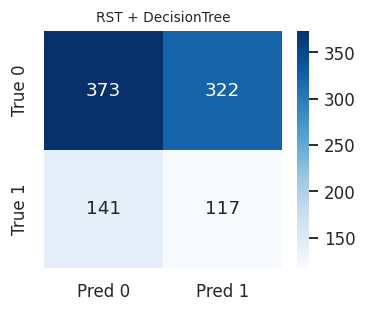

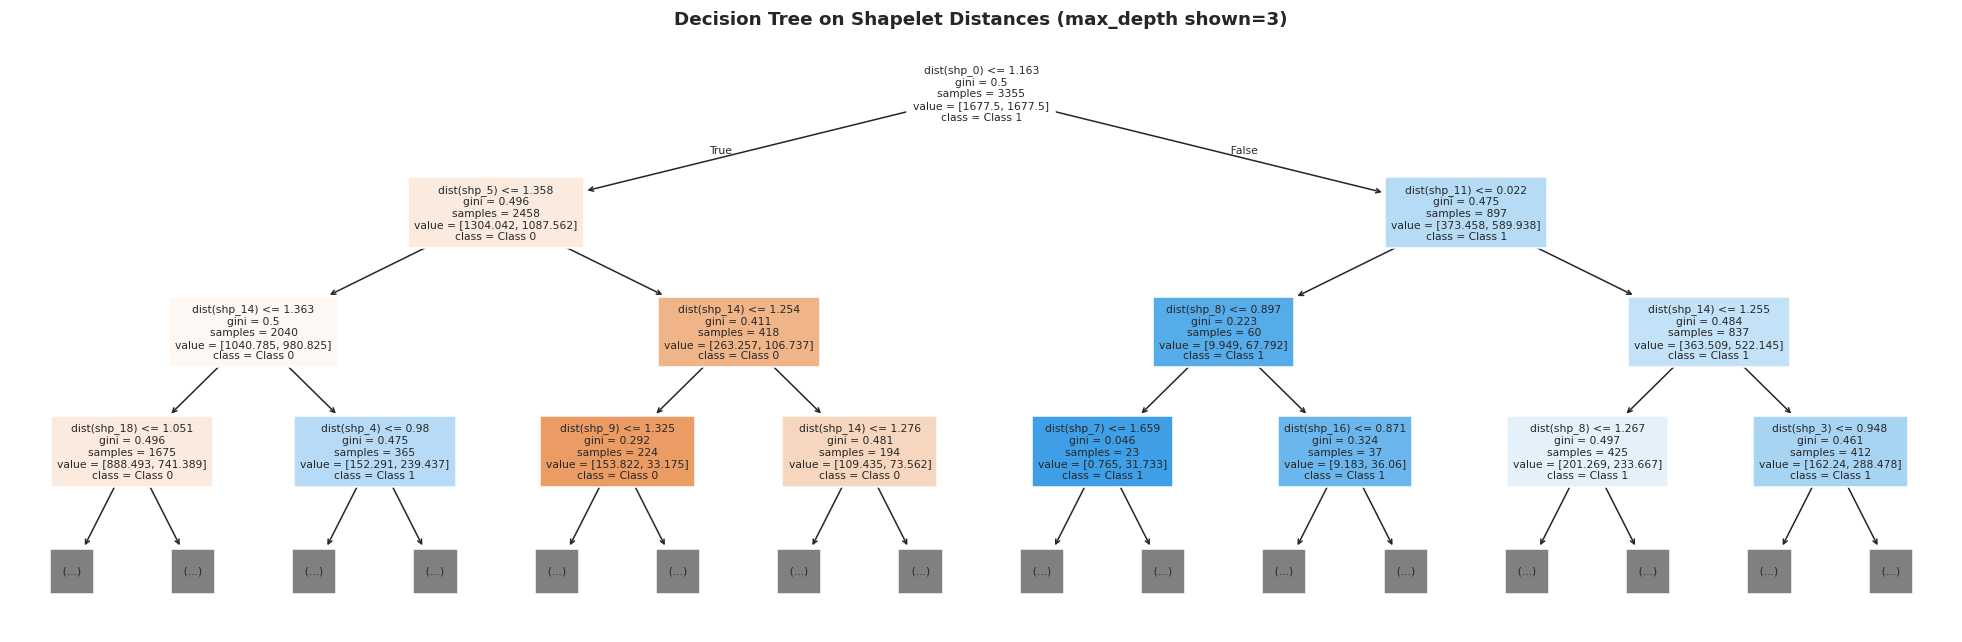

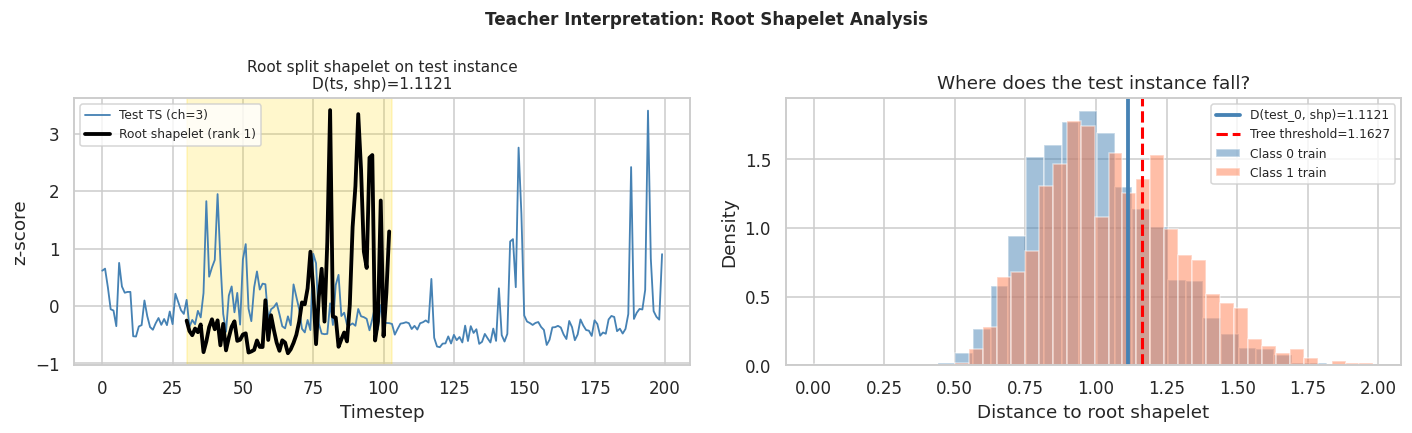

Root shapelet: index=0  IG=0.01357  len=73  ch=3  pos=30
Decision: dist=1.1121 <= threshold=1.1627  → left branch (Class 0)


In [10]:
n0, n1 = np.bincount(y_train)

dt = DecisionTreeClassifier(
    max_depth    = 6,
    class_weight = "balanced",
    random_state = SEED
)
dt.fit(np.array(Xtr_shape), y_train)
pred_dt  = dt.predict(np.array(Xte_shape))
proba_dt = dt.predict_proba(np.array(Xte_shape))[:, 1]
evaluate_model("RST + DecisionTree", y_test, pred_dt, proba_dt)

# ── Teacher Cell 101: plot the decision tree ──────────────────────────────
plt.figure(figsize=(18, 6))
plot_tree(dt,
          class_names=["Class 0", "Class 1"],
          feature_names=[f"dist(shp_{i})" for i in range(np.array(Xtr_shape).shape[1])],
          filled=True, max_depth=3, fontsize=7)
plt.title("Decision Tree on Shapelet Distances (max_depth shown=3)", fontweight='bold')
plt.tight_layout(); plt.show()

# ── Teacher Cell 102: plot root shapelet on a test instance ───────────────
root_shp_idx = dt.tree_.feature[0]
root_shapelet = shapelets[root_shp_idx]
sv_root = np.array(root_shapelet[6]).flatten()
root_pos = int(root_shapelet[2])
root_ch  = int(root_shapelet[3])
root_orig_ch = BEST_CH[root_ch] if root_ch < len(BEST_CH) else root_ch
root_dist = np.array(Xte_shape)[0, root_shp_idx]

fig3, axes3 = plt.subplots(1, 2, figsize=(13, 4))

# Left: test TS with shapelet at its matching position
test_ts = Xte_z[0, :, root_orig_ch]
axes3[0].plot(test_ts, color='steelblue', lw=1.2, label='Test TS (ch={})'.format(root_orig_ch))
axes3[0].plot(np.arange(root_pos, root_pos + len(sv_root)), sv_root,
              color='black', lw=2.5, label=f'Root shapelet (rank {root_shp_idx+1})')
axes3[0].axvspan(root_pos, root_pos + len(sv_root), alpha=0.2, color='gold')
axes3[0].set_title(f'Root split shapelet on test instance\nD(ts, shp)={root_dist:.4f}', fontsize=10)
axes3[0].set_xlabel('Timestep'); axes3[0].set_ylabel('z-score'); axes3[0].legend(fontsize=8)

# Right: distance vs threshold interpretation
threshold = dt.tree_.threshold[0]
axes3[1].axvline(root_dist, color='steelblue', lw=2.5, label=f'D(test_0, shp)={root_dist:.4f}')
axes3[1].axvline(threshold, color='red', ls='--', lw=2, label=f'Tree threshold={threshold:.4f}')
d_all_0 = feat_arr[:, root_shp_idx][y_train==0]
d_all_1 = feat_arr[:, root_shp_idx][y_train==1]
axes3[1].hist(d_all_0, bins=30, alpha=0.5, color='steelblue', density=True, label='Class 0 train')
axes3[1].hist(d_all_1, bins=30, alpha=0.5, color='coral',     density=True, label='Class 1 train')
axes3[1].set_xlabel('Distance to root shapelet')
axes3[1].set_ylabel('Density')
axes3[1].set_title('Where does the test instance fall?')
axes3[1].legend(fontsize=8)

plt.suptitle('Teacher Interpretation: Root Shapelet Analysis', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Root shapelet: index={root_shp_idx}  IG={float(root_shapelet[0]):.5f}  "
      f"len={int(root_shapelet[1])}  ch={root_orig_ch}  pos={root_pos}")
print(f"Decision: dist={root_dist:.4f} {'<=' if root_dist <= threshold else '>'} threshold={threshold:.4f}"
      f"  → {'left branch (Class 0)' if root_dist <= threshold else 'right branch (Class 1)'}")

## Cell 13 — RST + Logistic Regression *(Teacher's linear variant)*

  RST + Logistic Regression
  Accuracy          0.5446
  Balanced Accuracy 0.5245
  Macro F1          0.5045
  ROC-AUC           0.5521

              precision    recall  f1-score   support

     Class 0       0.75      0.57      0.65       695
     Class 1       0.29      0.48      0.36       258

    accuracy                           0.54       953
   macro avg       0.52      0.52      0.50       953
weighted avg       0.62      0.54      0.57       953



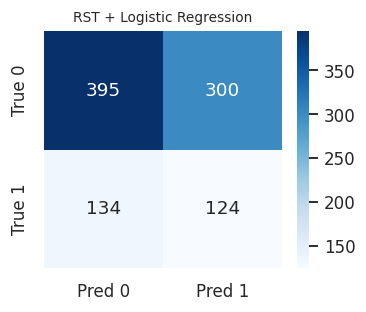

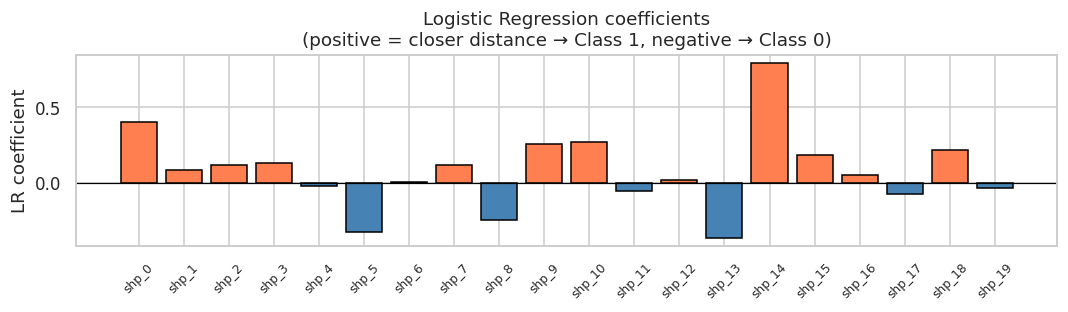

Most positive shapelet: shp_14  coef=0.7920
Most negative shapelet: shp_13  coef=-0.3647


In [11]:
lr = LogisticRegression(
    class_weight = "balanced",
    max_iter     = 2000,
    C            = 0.1,           # regularised — avoids overfitting on 20 features
    random_state = SEED
)
lr.fit(np.array(Xtr_shape), y_train)
pred_lr  = lr.predict(np.array(Xte_shape))
proba_lr = lr.predict_proba(np.array(Xte_shape))[:, 1]
evaluate_model("RST + Logistic Regression", y_test, pred_lr, proba_lr)

# Coefficients show which shapelet distance matters most
coefs = lr.coef_[0]
fig4, ax4 = plt.subplots(figsize=(10, 3))
colors_c = ['coral' if c > 0 else 'steelblue' for c in coefs]
ax4.bar(range(len(coefs)), coefs, color=colors_c, edgecolor='k')
ax4.set_xticks(range(len(coefs)))
ax4.set_xticklabels([f'shp_{i}' for i in range(len(coefs))], rotation=45, fontsize=8)
ax4.set_ylabel('LR coefficient')
ax4.set_title('Logistic Regression coefficients\n(positive = closer distance → Class 1, negative → Class 0)')
ax4.axhline(0, color='black', lw=0.8)
plt.tight_layout(); plt.show()
print(f"Most positive shapelet: shp_{np.argmax(coefs)}  coef={coefs.max():.4f}")
print(f"Most negative shapelet: shp_{np.argmin(coefs)}  coef={coefs.min():.4f}")

## Cell 14 — RST + XGBoost

XGBoost fit in 1s
  RST + XGBoost
  Accuracy          0.5761
  Balanced Accuracy 0.4973
  Macro F1          0.4954
  ROC-AUC           0.5116

              precision    recall  f1-score   support

     Class 0       0.73      0.67      0.70       695
     Class 1       0.27      0.33      0.29       258

    accuracy                           0.58       953
   macro avg       0.50      0.50      0.50       953
weighted avg       0.60      0.58      0.59       953



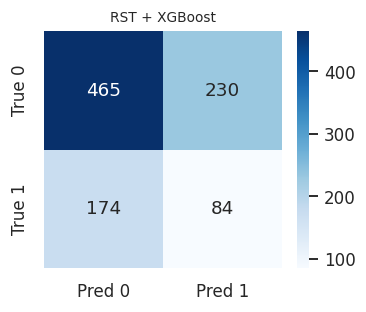

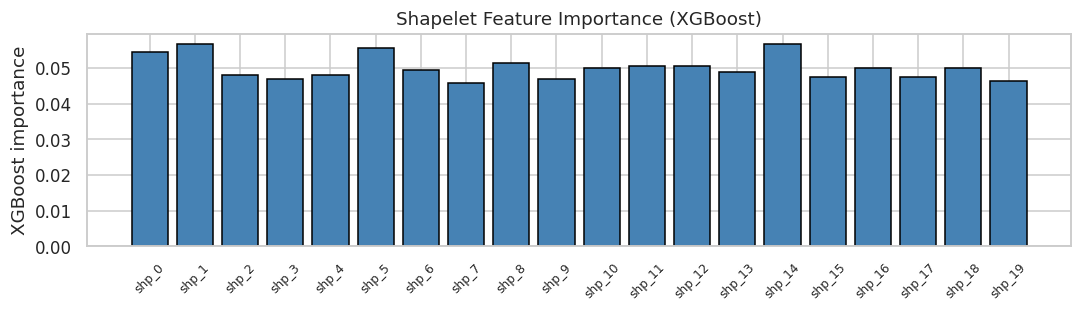

Most important shapelet: shp_1  importance=0.0567


In [12]:
n0, n1 = np.bincount(y_train)
xgb = XGBClassifier(
    n_estimators     = 500,
    max_depth        = 5,
    learning_rate    = 0.03,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    scale_pos_weight = n0 / n1,
    random_state     = SEED,
    n_jobs           = -1
)
t0 = time.time()
xgb.fit(np.array(Xtr_shape), y_train)
print(f"XGBoost fit in {time.time()-t0:.0f}s")
pred_xgb  = xgb.predict(np.array(Xte_shape))
proba_xgb = xgb.predict_proba(np.array(Xte_shape))[:, 1]
evaluate_model("RST + XGBoost", y_test, pred_xgb, proba_xgb)

# Feature importance
fi = xgb.feature_importances_
fig5, ax5 = plt.subplots(figsize=(10, 3))
ax5.bar(range(len(fi)), fi, color='steelblue', edgecolor='k')
ax5.set_xticks(range(len(fi)))
ax5.set_xticklabels([f'shp_{i}' for i in range(len(fi))], rotation=45, fontsize=8)
ax5.set_ylabel('XGBoost importance'); ax5.set_title('Shapelet Feature Importance (XGBoost)')
plt.tight_layout(); plt.show()
print(f"Most important shapelet: shp_{np.argmax(fi)}  importance={fi.max():.4f}")

## Cell 15 — RDSTClassifier *(Teacher's aeon method — fastest shapelet)*

**RDST (Random Dilated Shapelet Transform)** — the teacher uses this from `aeon`. Key advantages:
- Uses **dilation** (sparse sampling along the series) so short shapelets can capture long-range patterns
- 10–100× faster than RST because it avoids pairwise distance computations
- Requires **float64** input (numba typing)

Fitting RDST on (3355, 7, 200) ...
Done in 78s
  RDSTClassifier (aeon)
  Accuracy          0.7083
  Balanced Accuracy 0.5295
  Macro F1          0.5135
  ROC-AUC           0.5295

              precision    recall  f1-score   support

     Class 0       0.74      0.92      0.82       695
     Class 1       0.39      0.14      0.21       258

    accuracy                           0.71       953
   macro avg       0.57      0.53      0.51       953
weighted avg       0.65      0.71      0.65       953



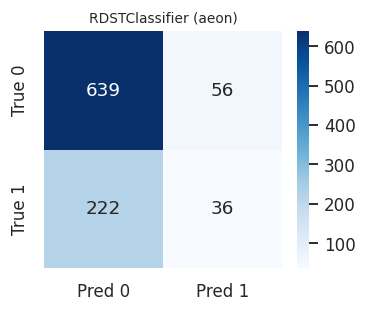

In [13]:
# RDST requires float64 — already ensured in preprocessing
rdst = RDSTClassifier(
    max_shapelets = 100,
    random_state  = SEED
)
print(f"Fitting RDST on {Xtr_sk_all.shape} ...")
t0 = time.time()
rdst.fit(Xtr_sk_all, y_train)
print(f"Done in {time.time()-t0:.0f}s")
pred_rdst  = rdst.predict(Xte_sk_all)
proba_rdst = rdst.predict_proba(Xte_sk_all)[:, 1]
evaluate_model("RDSTClassifier (aeon)", y_test, pred_rdst, proba_rdst)

## Cell 16 — ShapeletTransformClassifier *(Teacher's end-to-end pipeline)*

  ShapeletTransformClassifier
  Accuracy          0.6873
  Balanced Accuracy 0.5102
  Macro F1          0.4919
  ROC-AUC           0.5315

              precision    recall  f1-score   support

     Class 0       0.73      0.90      0.81       695
     Class 1       0.31      0.12      0.18       258

    accuracy                           0.69       953
   macro avg       0.52      0.51      0.49       953
weighted avg       0.62      0.69      0.64       953



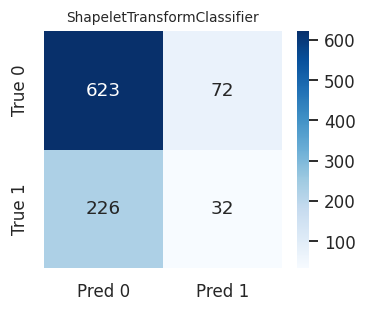

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

shapelet_transform = RandomShapeletTransform(
    n_shapelet_samples=500,
    max_shapelets=15,
    min_shapelet_length=30,
    max_shapelet_length=100,
    random_state=SEED
)

stc_pipeline = Pipeline([
    ('shapelet', shapelet_transform),
    ('classifier', RandomForestClassifier(n_estimators=100))   # fixed typo
])

stc_pipeline.fit(Xtr_sk_sel, y_train)
pred_stc = stc_pipeline.predict(Xte_sk_sel)
proba_stc = stc_pipeline.predict_proba(Xte_sk_sel)[:, 1]
evaluate_model("ShapeletTransformClassifier", y_test, pred_stc, proba_stc)

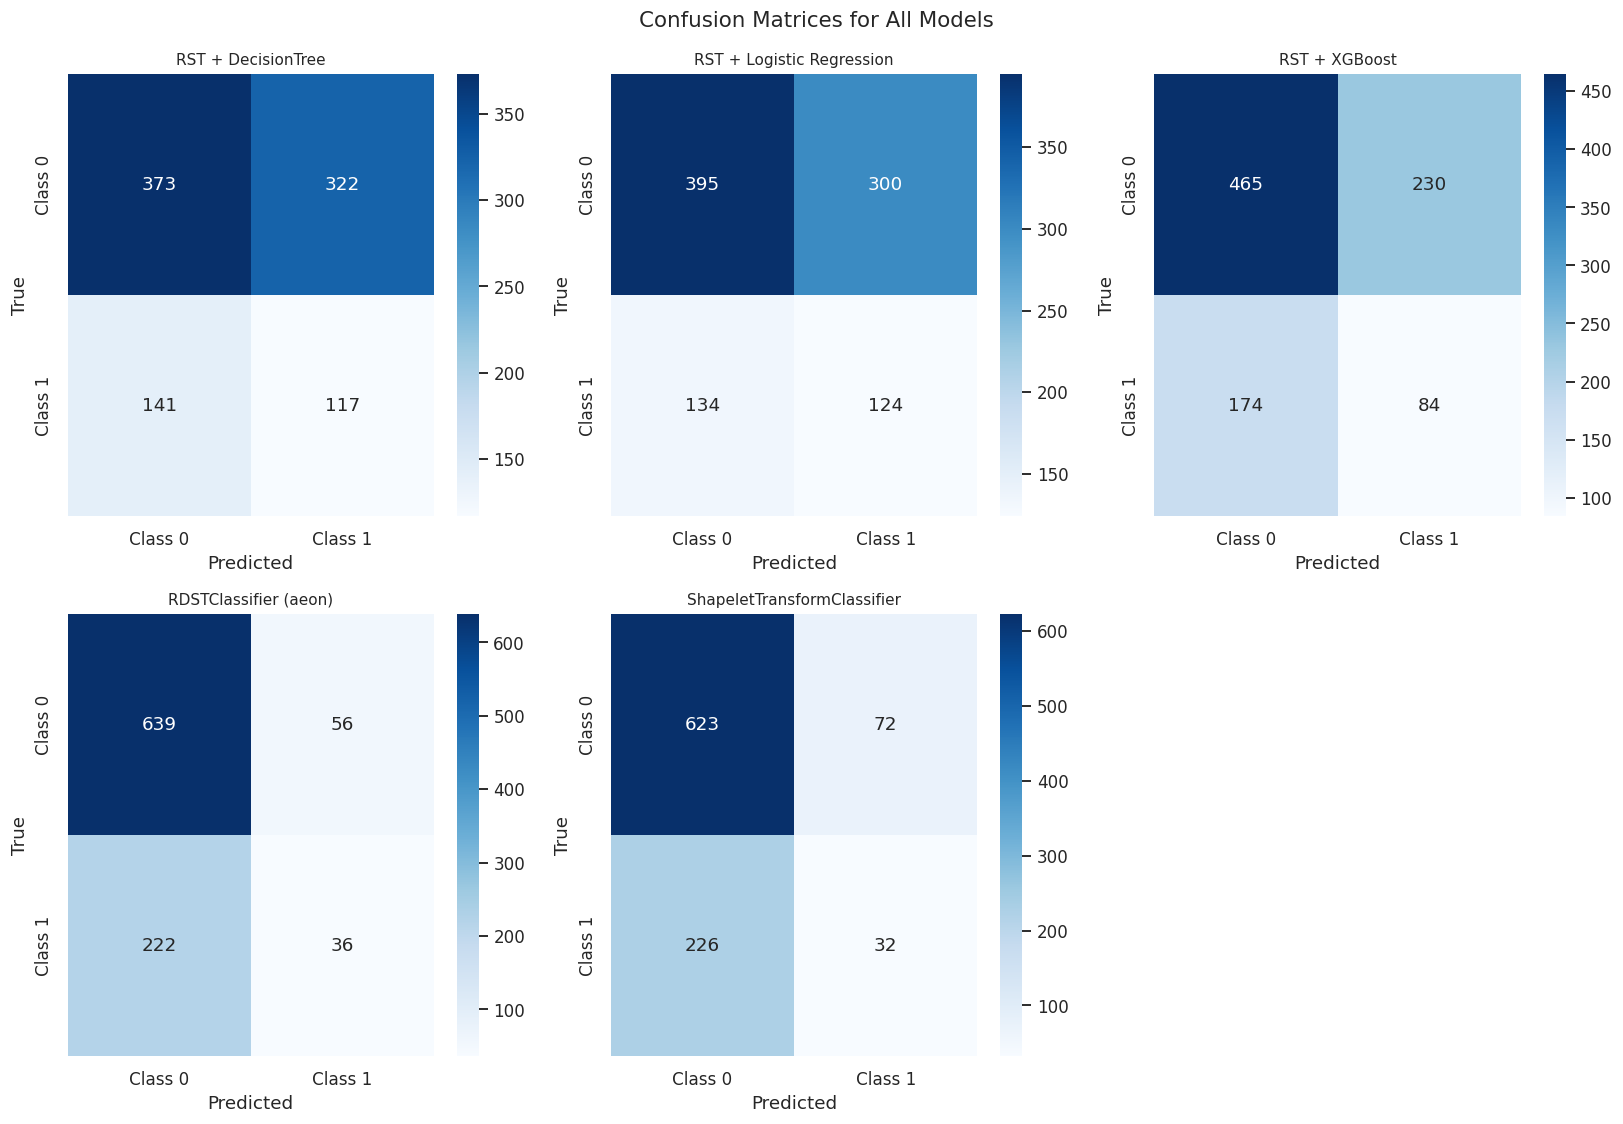

In [15]:
# ===== Combined Confusion Matrix Plot =====
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# List of (model_name, predictions, true_labels)
models = [
    ('RST + DecisionTree', pred_dt, y_test),
    ('RST + Logistic Regression', pred_lr, y_test),
    ('RST + XGBoost', pred_xgb, y_test),
    ('RDSTClassifier (aeon)', pred_rdst, y_test),
    ('ShapeletTransformClassifier', pred_stc, y_test)
]

# Create a 2x3 grid (one extra slot if needed)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, pred, true) in enumerate(models):
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Class 0', 'Class 1'],
                yticklabels=['Class 0', 'Class 1'],
                ax=axes[i])
    axes[i].set_title(name, fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

# Hide any unused subplot (if fewer than 6 models)
if len(models) < 6:
    for j in range(len(models), 6):
        axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('Confusion Matrices for All Models', y=1.02, fontsize=14)
plt.show()

---
# Section D — Motif / Discord / Shapelet Bridge

| Concept | Tool | Score | Role |
|---|---|---|---|
| **Motif** | STUMPY (matrix profile) | MP minimum | Most recurring sub-sequence |
| **Discord** | STUMPY (matrix profile) | MP maximum | Most anomalous sub-sequence |
| **Shapelet** | RandomShapeletTransform | F-stat / IG | Best class discriminator |

**Bridge:** a motif that appears predominantly in one class is a shapelet. The analysis below tests this.

## Cell 20 — Motif & Discord Analysis

Selected M = 10


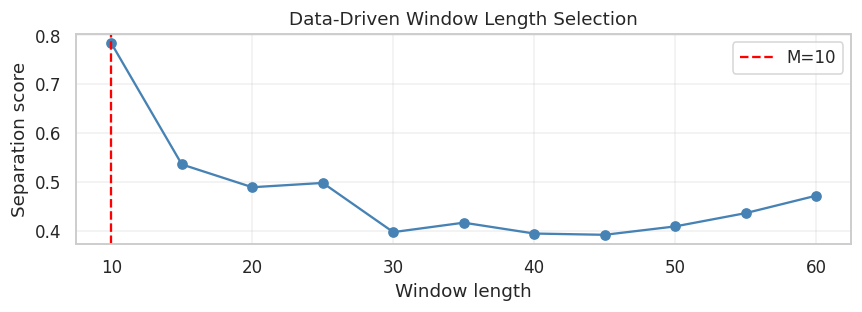

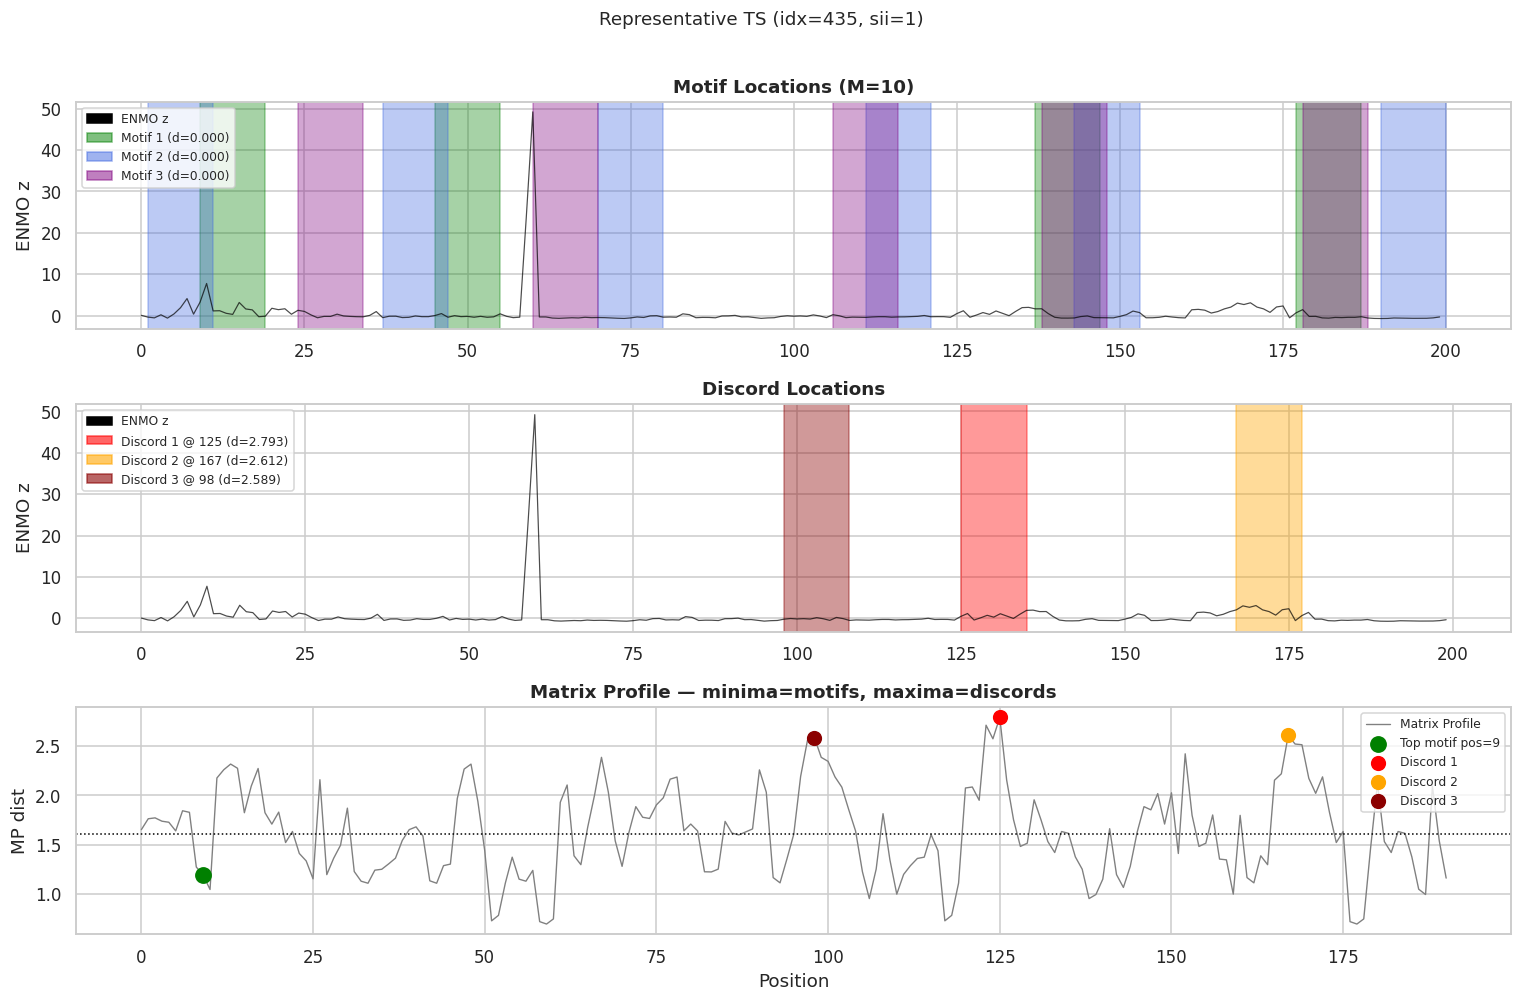

In [16]:
try:
    import stumpy
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'stumpy', '-q'])
    import stumpy

from scipy.stats import mannwhitneyu as mwu
from scipy.spatial.distance import euclidean as l2
import matplotlib.patches as mpatches

ENMO_IDX = 3
enmo_z = Xtr_z[:, :, ENMO_IDX].copy()

# Window length selection
ref_ts = enmo_z[np.where(y_train == 0)[0][0]]
m_range, sep = np.arange(10, 61, 5), []
for m in m_range:
    mp = stumpy.stump(ref_ts, m)[:,0].astype(float)
    sep.append((np.max(mp) - np.min(mp)) / (np.max(mp) + 1e-8))
M = int(m_range[np.argmax(sep)])
print(f"Selected M = {M}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(m_range, sep, 'o-', color='steelblue', lw=1.5)
ax.axvline(M, color='red', ls='--', label=f'M={M}')
ax.set_xlabel('Window length'); ax.set_ylabel('Separation score')
ax.set_title('Data-Driven Window Length Selection'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Representative TS
rep_idx = int(np.argmax(X_train[:, :, ENMO_IDX].std(axis=1)))
ts_rep  = enmo_z[rep_idx]
mp_rep  = stumpy.stump(ts_rep, M)
mp_dist = mp_rep[:,0].astype(float)
mp_dist[np.isinf(mp_dist)] = np.nan

def no_overlap(positions, gap):
    out = []
    for p in sorted(positions):
        if all(abs(p-s) >= gap for s in out): out.append(p)
    return out

def get_discords(mp, excl, k=3):
    mp_c, out = mp.copy(), []
    for _ in range(k):
        pos = int(np.nanargmax(mp_c))
        out.append((pos, float(mp_c[pos])))
        mp_c[max(0,pos-excl):pos+excl+1] = -np.inf
    return out

motif_dist_arr, motif_idx_arr = stumpy.motifs(
    ts_rep, mp_rep[:,0], max_motifs=3, cutoff=np.inf, min_neighbors=1)
fmotifs = [no_overlap([int(p) for p in motif_idx_arr[i] if p>=0], 3*M)
           for i in range(len(motif_dist_arr))]
discords = get_discords(mp_dist, excl=M//2, k=3)

mc = ['green','royalblue','purple']; dc = ['red','orange','darkred']
fig2, axs = plt.subplots(3, 1, figsize=(14, 9), sharex=False)

axs[0].plot(ts_rep, color='black', lw=0.8, alpha=0.7)
h0 = [mpatches.Patch(color='black', label='ENMO z')]
for i, pos_list in enumerate(fmotifs):
    for pos in pos_list:
        axs[0].axvspan(pos, min(pos+M, T), alpha=0.35, color=mc[i])
    h0.append(mpatches.Patch(color=mc[i], alpha=0.5,
              label=f'Motif {i+1} (d={float(motif_dist_arr[i][0]):.3f})'))
axs[0].legend(handles=h0, fontsize=8)
axs[0].set_title(f'Motif Locations (M={M})', fontweight='bold'); axs[0].set_ylabel('ENMO z')

axs[1].plot(ts_rep, color='black', lw=0.8, alpha=0.7)
h1 = [mpatches.Patch(color='black', label='ENMO z')]
for i, (pos, dist) in enumerate(discords):
    axs[1].axvspan(pos, min(pos+M, T), alpha=0.4, color=dc[i])
    h1.append(mpatches.Patch(color=dc[i], alpha=0.6,
              label=f'Discord {i+1} @ {pos} (d={dist:.3f})'))
axs[1].legend(handles=h1, fontsize=8)
axs[1].set_title('Discord Locations', fontweight='bold'); axs[1].set_ylabel('ENMO z')

axs[2].plot(mp_dist, color='gray', lw=0.9, label='Matrix Profile')
mot_pos0 = fmotifs[0][0] if fmotifs[0] else int(np.nanargmin(mp_dist))
axs[2].scatter(mot_pos0, mp_dist[mot_pos0], color='green', s=100, zorder=5, label=f'Top motif pos={mot_pos0}')
for i, (pos, dist) in enumerate(discords):
    axs[2].scatter(pos, dist, color=dc[i], s=80, zorder=5, label=f'Discord {i+1}')
axs[2].axhline(np.nanmean(mp_dist), color='black', ls=':', lw=1)
axs[2].set_title('Matrix Profile — minima=motifs, maxima=discords', fontweight='bold')
axs[2].set_xlabel('Position'); axs[2].set_ylabel('MP dist'); axs[2].legend(fontsize=8)

plt.suptitle(f'Representative TS (idx={rep_idx}, sii={int(y_train[rep_idx])})', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

## Cell 21 — Global MP + Consensus Motif + Shapelet Bridge

Computing global matrix profiles (N=3355, M=10) ...
  500/3355
  1000/3355
  1500/3355
  2000/3355
  2500/3355
  3000/3355
Class summary:
     regularity  discord_dist
sii                          
0        0.6943        2.7637
1        0.6895        2.7601
Consensus L2 distance: 0.3989


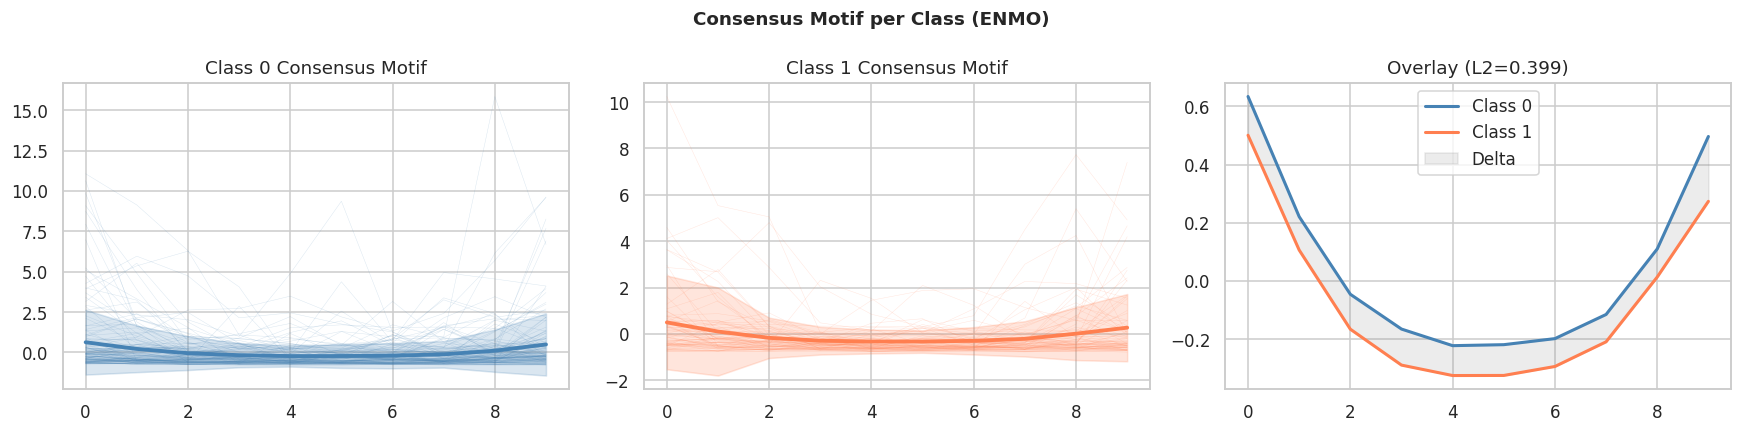

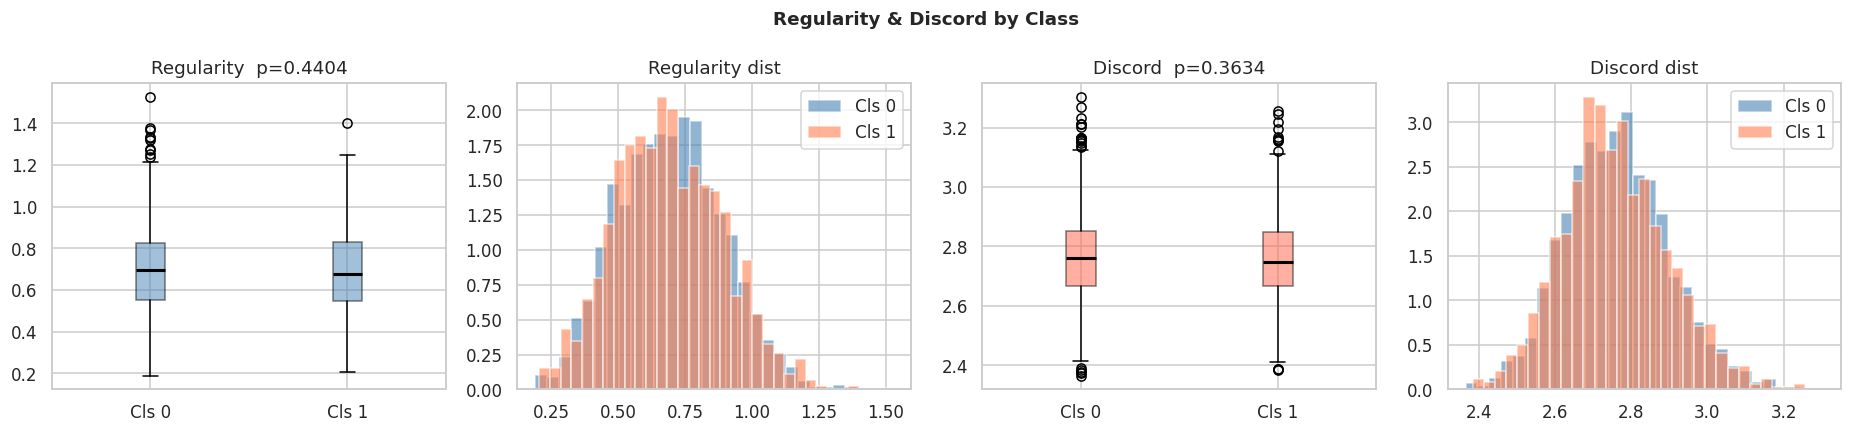

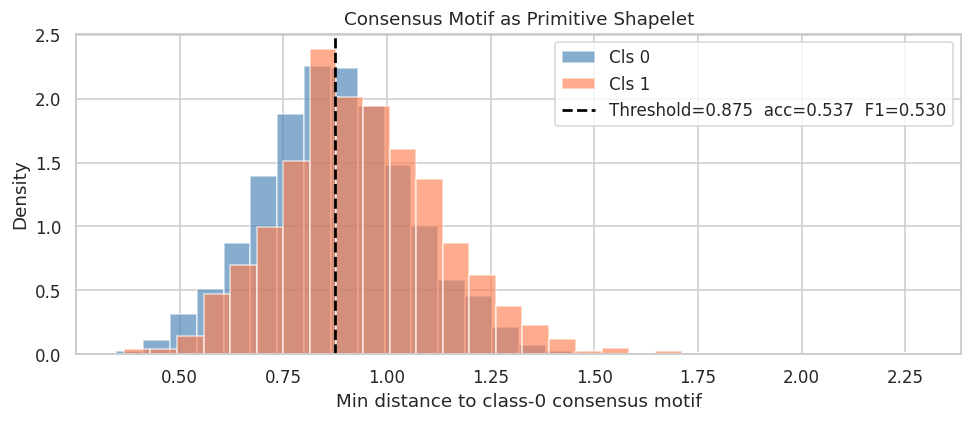

Primitive shapelet accuracy: 0.5365  F1: 0.5301
Regularity  cls0=0.6943  cls1=0.6895  p=0.4404
Discord     cls0=2.7637  cls1=2.7601  p=0.3634


In [17]:
print(f'Computing global matrix profiles (N={N_TRAIN}, M={M}) ...')
global_rows = []; consensus = {0:[], 1:[]}

for i in range(N_TRAIN):
    mp_i = stumpy.stump(enmo_z[i], M)
    mp_v = mp_i[:,0].astype(float); mp_v[np.isinf(mp_v)] = np.nan
    mot_pos = int(np.nanargmin(mp_v))
    disc    = get_discords(mp_v, excl=M//2, k=1)[0]
    sii     = int(y_train[i])
    global_rows.append({'sii': sii, 'regularity': float(mp_v[mot_pos]),
                        'discord_dist': disc[1], 'motif_pos': mot_pos})
    seg = enmo_z[i, mot_pos:mot_pos+M]
    if len(seg) == M: consensus[sii].append(seg)
    if (i+1) % 500 == 0: print(f'  {i+1}/{N_TRAIN}')

gdf = pd.DataFrame(global_rows)
print('Class summary:')
print(gdf.groupby('sii')[['regularity','discord_dist']].mean().round(4))

shapes0 = np.array(consensus[0]); shapes1 = np.array(consensus[1])
mean0, std0 = shapes0.mean(0), shapes0.std(0)
mean1, std1 = shapes1.mean(0), shapes1.std(0)
t_sub = np.arange(M)
print(f'Consensus L2 distance: {l2(mean0, mean1):.4f}')

fig3, axs3 = plt.subplots(1, 3, figsize=(16, 4))
for seg in shapes0[::15]: axs3[0].plot(t_sub, seg, color='steelblue', lw=0.3, alpha=0.2)
axs3[0].plot(t_sub, mean0, color='steelblue', lw=2.5); axs3[0].fill_between(t_sub, mean0-std0, mean0+std0, alpha=0.2, color='steelblue')
axs3[0].set_title('Class 0 Consensus Motif')

for seg in shapes1[::15]: axs3[1].plot(t_sub, seg, color='coral', lw=0.3, alpha=0.2)
axs3[1].plot(t_sub, mean1, color='coral', lw=2.5); axs3[1].fill_between(t_sub, mean1-std1, mean1+std1, alpha=0.2, color='coral')
axs3[1].set_title('Class 1 Consensus Motif')

axs3[2].plot(t_sub, mean0, color='steelblue', lw=2, label='Class 0')
axs3[2].plot(t_sub, mean1, color='coral', lw=2, label='Class 1')
axs3[2].fill_between(t_sub, mean0, mean1, alpha=0.15, color='gray', label='Delta')
axs3[2].set_title(f'Overlay (L2={l2(mean0, mean1):.3f})'); axs3[2].legend()

plt.suptitle('Consensus Motif per Class (ENMO)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Stats
reg0  = gdf[gdf.sii==0]['regularity'].values;  reg1  = gdf[gdf.sii==1]['regularity'].values
disc0 = gdf[gdf.sii==0]['discord_dist'].values; disc1 = gdf[gdf.sii==1]['discord_dist'].values
_, p_reg  = mwu(reg0, reg1, alternative='two-sided')
_, p_disc = mwu(disc0, disc1, alternative='two-sided')

fig4, axs4 = plt.subplots(1, 4, figsize=(17, 4))
axs4[0].boxplot([reg0, reg1], labels=['Cls 0','Cls 1'], patch_artist=True,
                boxprops=dict(facecolor='steelblue',alpha=0.5), medianprops=dict(color='k',lw=2))
axs4[0].set_title(f'Regularity  p={p_reg:.4f}')
axs4[1].hist(reg0, bins=30, alpha=0.6, color='steelblue', density=True, label='Cls 0', edgecolor='w')
axs4[1].hist(reg1, bins=30, alpha=0.6, color='coral', density=True, label='Cls 1', edgecolor='w')
axs4[1].set_title('Regularity dist'); axs4[1].legend()
axs4[2].boxplot([disc0, disc1], labels=['Cls 0','Cls 1'], patch_artist=True,
                boxprops=dict(facecolor='tomato',alpha=0.5), medianprops=dict(color='k',lw=2))
axs4[2].set_title(f'Discord  p={p_disc:.4f}')
axs4[3].hist(disc0, bins=30, alpha=0.6, color='steelblue', density=True, label='Cls 0', edgecolor='w')
axs4[3].hist(disc1, bins=30, alpha=0.6, color='coral', density=True, label='Cls 1', edgecolor='w')
axs4[3].set_title('Discord dist'); axs4[3].legend()
plt.suptitle('Regularity & Discord by Class', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Shapelet bridge
min_dists = np.array([min(np.linalg.norm(enmo_z[i, j:j+M] - mean0)
                          for j in range(T - M + 1)) for i in range(N_TRAIN)])
thresh = np.median(min_dists[y_train==0])
pred_prim = (min_dists > thresh).astype(int)
acc_prim  = (pred_prim == y_train).mean()
f1_prim   = f1_score(y_train, pred_prim, average='macro')

fig5, ax5 = plt.subplots(figsize=(9, 4))
ax5.hist(min_dists[y_train==0], bins=30, alpha=0.65, color='steelblue', density=True, label='Cls 0', edgecolor='w')
ax5.hist(min_dists[y_train==1], bins=30, alpha=0.65, color='coral', density=True, label='Cls 1', edgecolor='w')
ax5.axvline(thresh, color='black', ls='--', lw=1.8, label=f'Threshold={thresh:.3f}  acc={acc_prim:.3f}  F1={f1_prim:.3f}')
ax5.set_xlabel('Min distance to class-0 consensus motif'); ax5.set_ylabel('Density')
ax5.set_title('Consensus Motif as Primitive Shapelet'); ax5.legend(); plt.tight_layout(); plt.show()

print(f'Primitive shapelet accuracy: {acc_prim:.4f}  F1: {f1_prim:.4f}')
print(f'Regularity  cls0={reg0.mean():.4f}  cls1={reg1.mean():.4f}  p={p_reg:.4f}')
print(f'Discord     cls0={disc0.mean():.4f}  cls1={disc1.mean():.4f}  p={p_disc:.4f}')

## Cell 21b — Motif Visualization & Shapelet Bridge Analysis

Detailed visualizations matching the reference figure style:
- **Left panel:** original ENMO time-series with highlighted motif occurrences per family
- **Right panel:** aligned shape overlay of all occurrences (motif family overlay)

All values extracted automatically from `fmotifs`, `motif_dist_arr`, and `shapelets`.

MOTIF ANALYSIS SUMMARY  (window M=10, 5.0h)

Motif 1:
  Occurrences : 4
  Best dist   : 0.0000
  Positions   : [9, 45, 137, 177]

Motif 2:
  Occurrences : 6
  Best dist   : 0.0000
  Positions   : [1, 37, 70, 111, 143, 190]

Motif 3:
  Occurrences : 5
  Best dist   : 0.0000
  Positions   : [24, 60, 106, 138, 178]


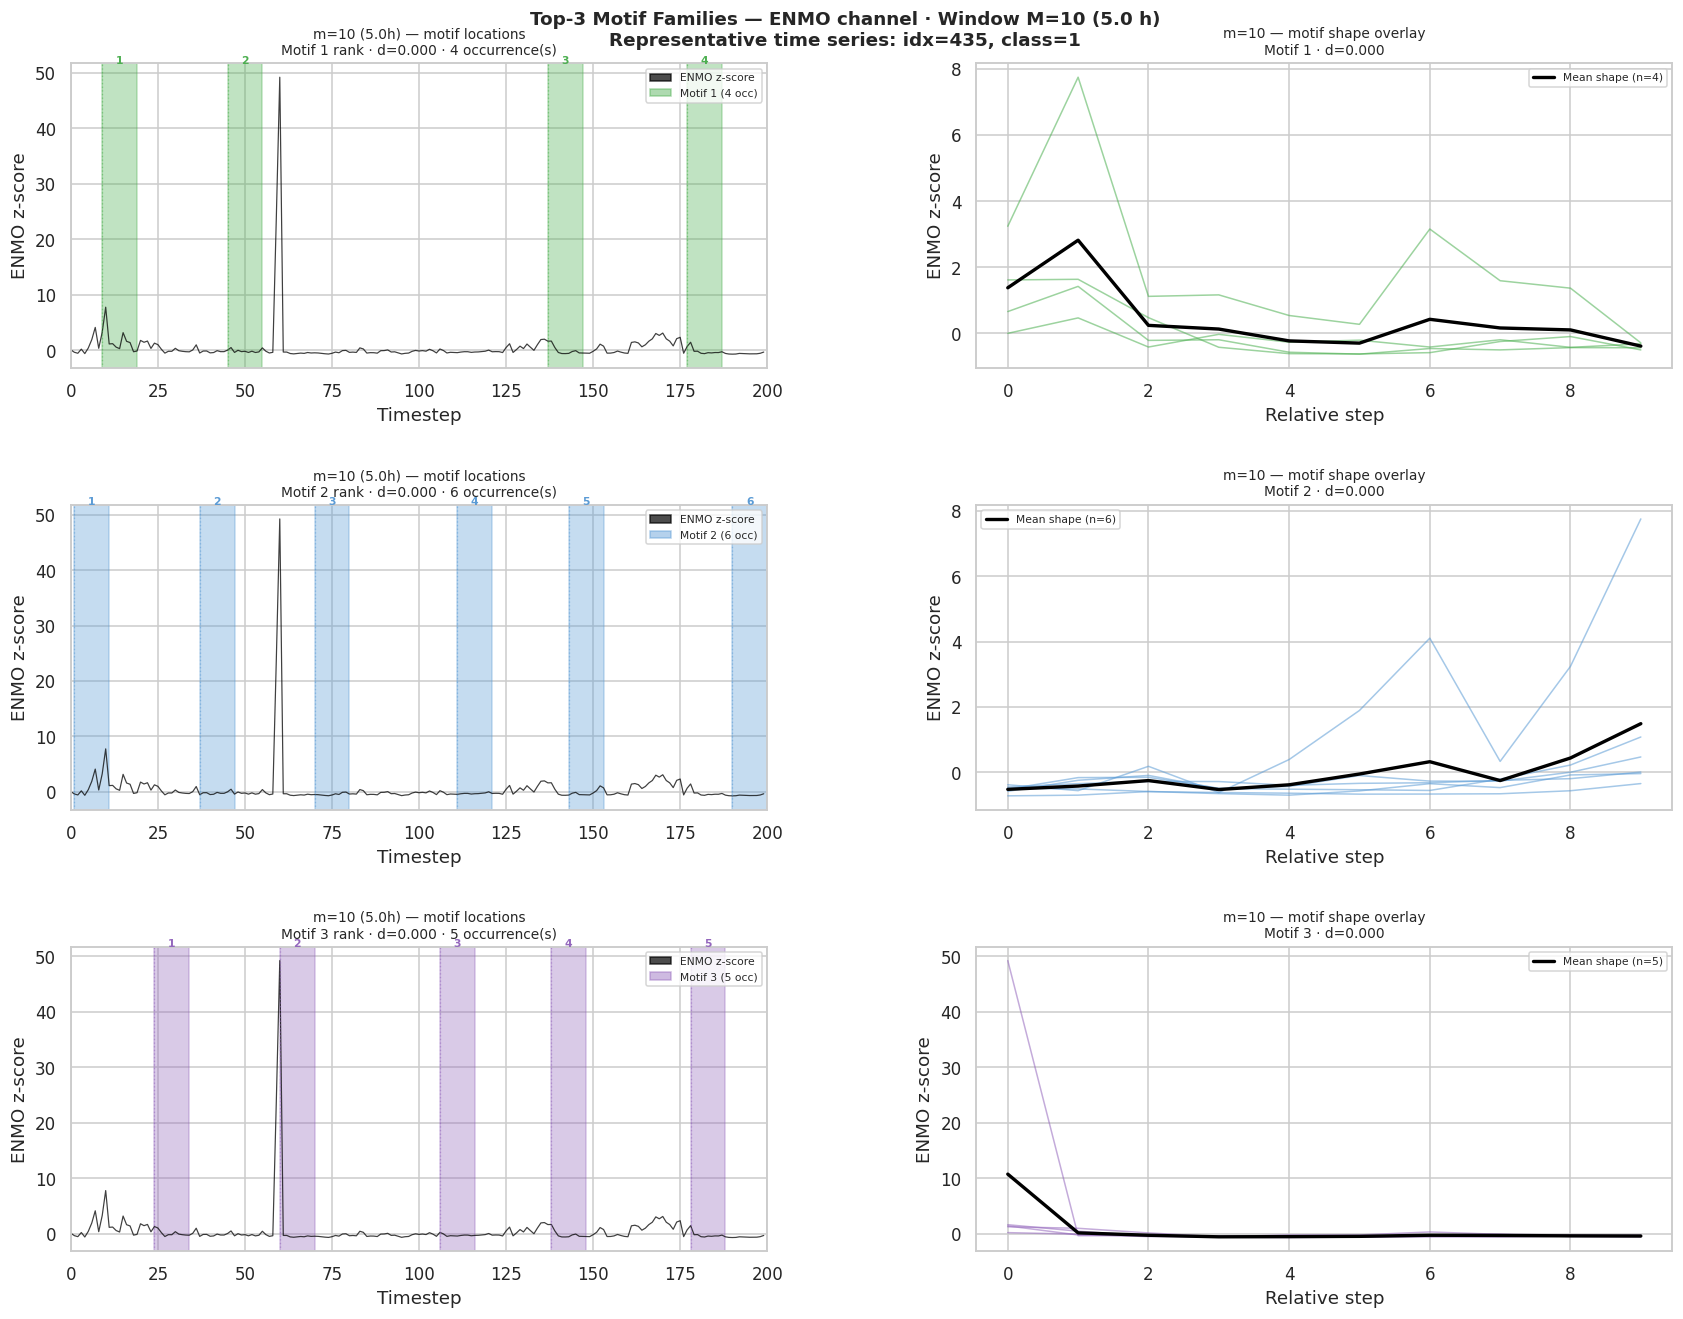

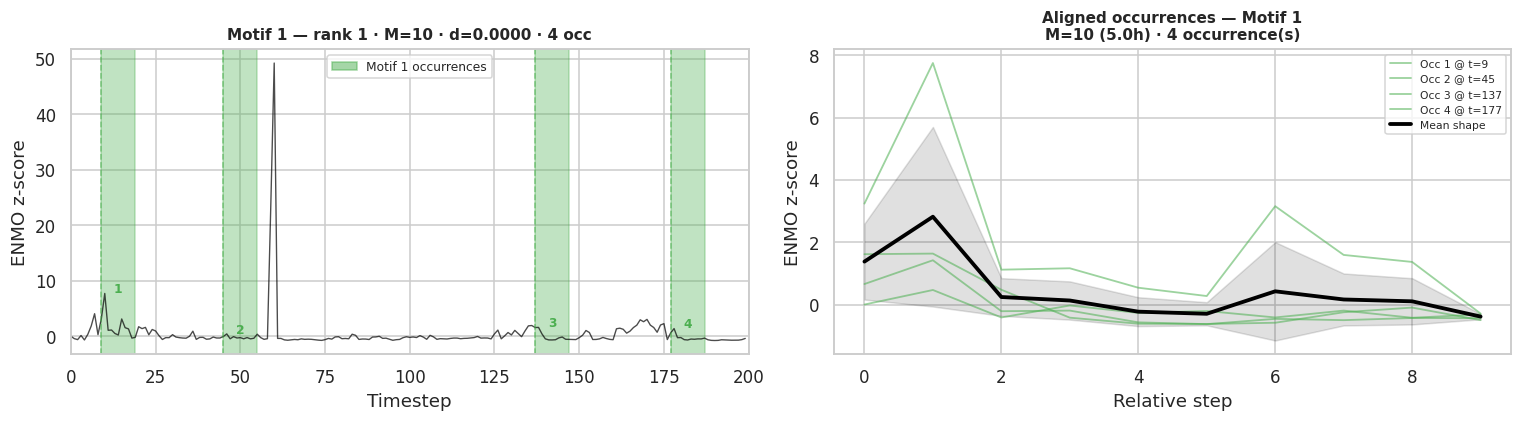

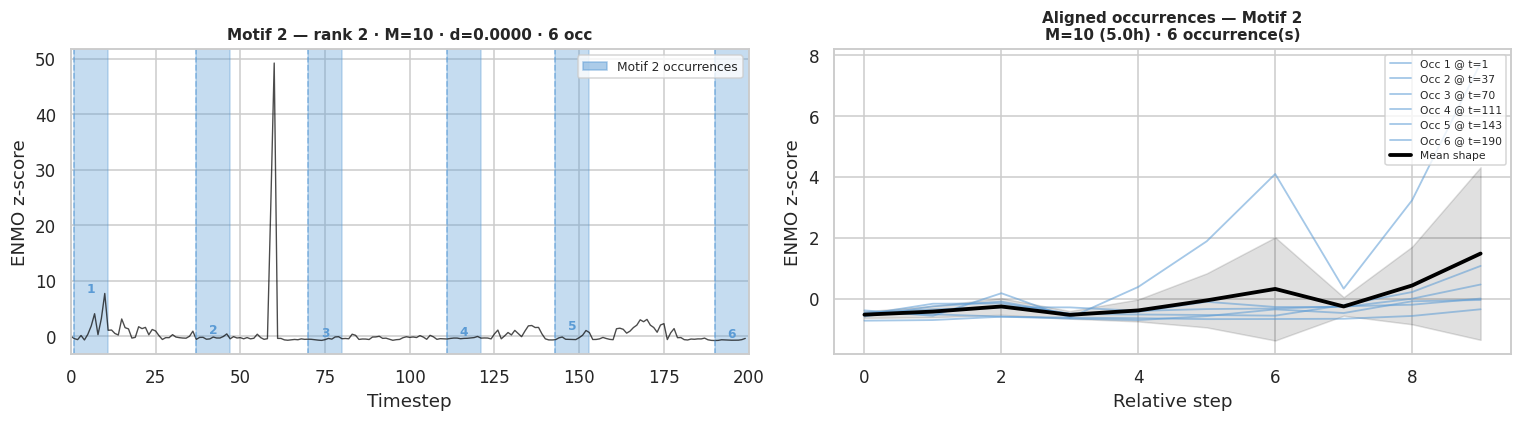

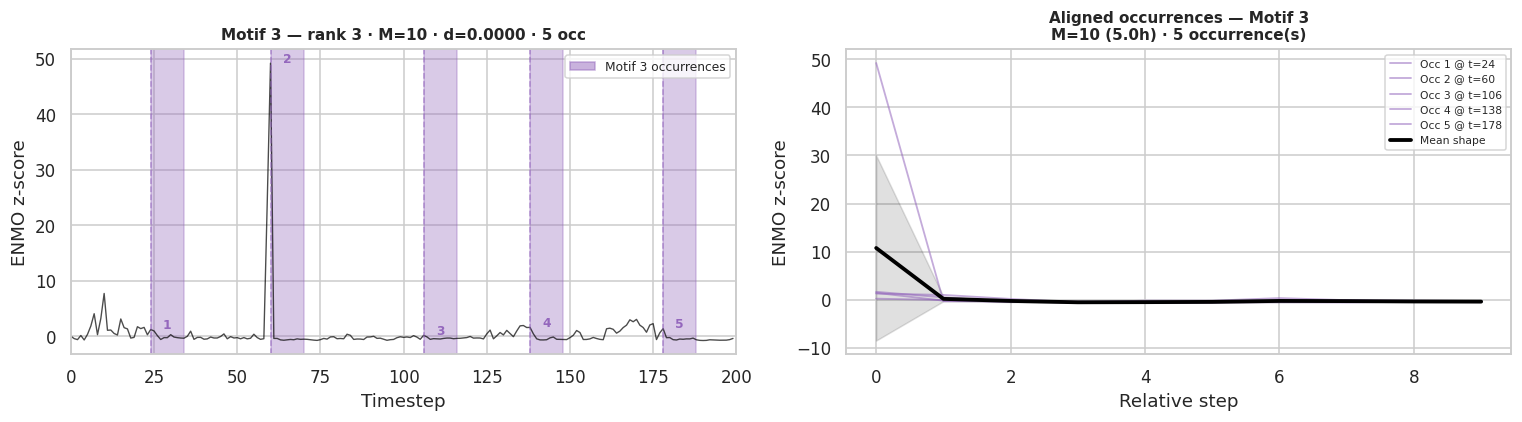


MOTIF ↔ SHAPELET RELATIONSHIP

Top RST shapelet: rank=1  IG=0.01357  len=73  pos=30  ch=3
Motif 1  pos=9  → overlaps shapelet region: False
Motif 2  pos=1  → overlaps shapelet region: False
Motif 3  pos=24  → overlaps shapelet region: True
(Shapelet longer than motif — skipping overlay in figure)


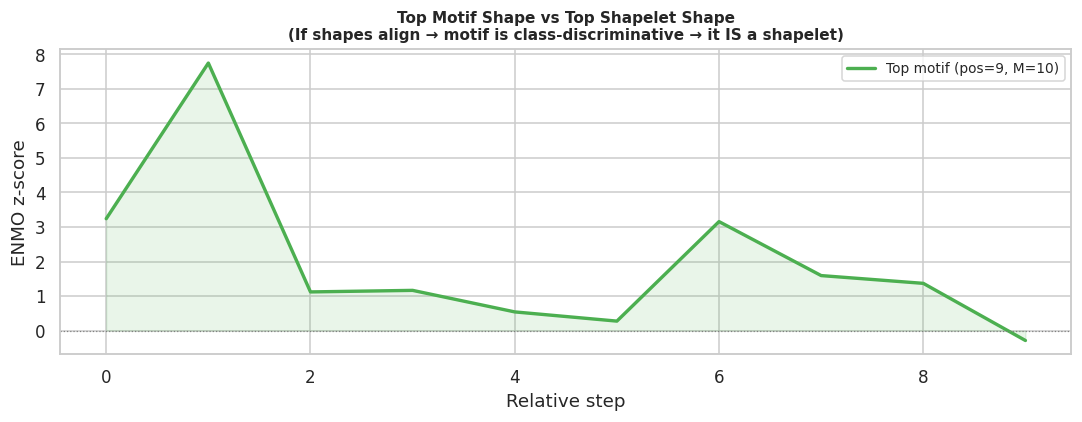

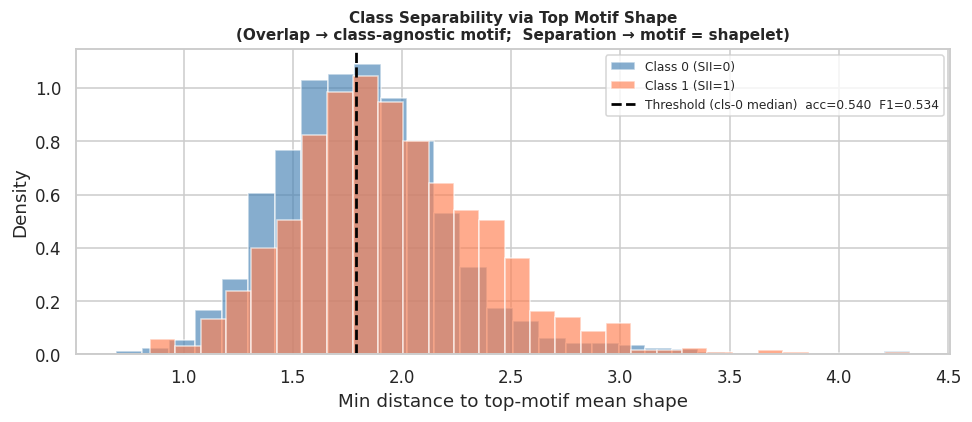


Top-motif discriminability test (Mann-Whitney U):
  p-value = 2.5897e-17
  Primitive shapelet accuracy  = 0.5398
  Primitive shapelet Macro-F1  = 0.5338
  → F1 ~ 0.50–0.55: WEAK discrimination; motif is partly class-specific


In [18]:
# ── Cell 21b: Motif Visualization & Shapelet Bridge ──────────────────────────
# Requires: fmotifs, motif_dist_arr, ts_rep, M, T, mc, enmo_z, y_train,
#           shapelets (from rst), sorted_sh, BEST_CH

import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

K_MOTIFS = len(fmotifs)               # number of motif families found
MOTIF_COLORS = ['#4CAF50', '#5B9BD5', '#9467BD'][:K_MOTIFS]  # green, blue, purple

# ─────────────────────────────────────────────────────────────────
# 1. TEXTUAL SUMMARY  (auto-generated from computed results)
# ─────────────────────────────────────────────────────────────────
print("=" * 60)
print(f"MOTIF ANALYSIS SUMMARY  (window M={M}, {M*0.5:.1f}h)")
print("=" * 60)
for i in range(K_MOTIFS):
    positions = fmotifs[i]
    n_occ     = len(positions)
    best_dist = float(motif_dist_arr[i][0]) if len(motif_dist_arr[i]) > 0 else float('nan')
    pos_str   = ', '.join(str(p) for p in positions)
    print(f"\nMotif {i+1}:")
    print(f"  Occurrences : {n_occ}")
    print(f"  Best dist   : {best_dist:.4f}")
    print(f"  Positions   : [{pos_str}]")

# ─────────────────────────────────────────────────────────────────
# 2. COMBINED FIGURE — all motif families in one grid
#    Left: TS + highlighted spans  |  Right: aligned shape overlay
# ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 4 * K_MOTIFS))
outer = gridspec.GridSpec(K_MOTIFS, 2, figure=fig, hspace=0.45, wspace=0.30,
                          left=0.06, right=0.97, top=0.94, bottom=0.04)

for i in range(K_MOTIFS):
    positions = fmotifs[i]
    n_occ     = len(positions)
    best_dist = float(motif_dist_arr[i][0]) if len(motif_dist_arr[i]) > 0 else float('nan')
    col       = MOTIF_COLORS[i]

    # ── Left: time-series with highlighted spans ──────────────────
    ax_ts = fig.add_subplot(outer[i, 0])
    ax_ts.plot(ts_rep, color='black', lw=0.8, alpha=0.75, label='ENMO z-score')
    handles = [mpatches.Patch(color='black', alpha=0.7, label='ENMO z-score')]
    for j, pos in enumerate(positions):
        end = min(pos + M, T)
        ax_ts.axvspan(pos, end, alpha=0.35, color=col,
                      label=f'Occurrence {j+1} @ t={pos}' if j == 0 else None)
        ax_ts.axvline(pos, color=col, lw=0.9, alpha=0.5, ls=':')
        ax_ts.text(pos + M/2, ax_ts.get_ylim()[1] if ax_ts.get_ylim()[1] > 0 else 1.0,
                   f'{j+1}', ha='center', fontsize=7, color=col, fontweight='bold')
    handles.append(mpatches.Patch(color=col, alpha=0.45,
                                  label=f'Motif {i+1} ({n_occ} occ)'))
    ax_ts.legend(handles=handles, fontsize=7, loc='upper right')
    ax_ts.set_title(
        f'm={M} ({M*0.5:.1f}h) — motif locations\n'
        f'Motif {i+1} rank · d={best_dist:.3f} · {n_occ} occurrence(s)',
        fontsize=9)
    ax_ts.set_xlabel('Timestep'); ax_ts.set_ylabel('ENMO z-score')
    ax_ts.set_xlim(0, T)

    # ── Right: aligned occurrences (shape overlay) ────────────────
    ax_ov = fig.add_subplot(outer[i, 1])
    t_rel = np.arange(M)
    valid_segs = []
    for pos in positions:
        seg = ts_rep[pos:pos + M]
        if len(seg) == M:
            valid_segs.append(seg)
            ax_ov.plot(t_rel, seg, color=col, lw=1.0, alpha=0.55)
    if valid_segs:
        mean_seg = np.mean(valid_segs, axis=0)
        ax_ov.plot(t_rel, mean_seg, color='black', lw=2.2,
                   label=f'Mean shape (n={len(valid_segs)})', zorder=5)
    ax_ov.legend(fontsize=7)
    ax_ov.set_title(
        f'm={M} — motif shape overlay\n'
        f'Motif {i+1} · d={best_dist:.3f}',
        fontsize=9)
    ax_ov.set_xlabel('Relative step'); ax_ov.set_ylabel('ENMO z-score')

fig.suptitle(
    f'Top-{K_MOTIFS} Motif Families — ENMO channel · Window M={M} ({M*0.5:.1f} h)\n'
    f'Representative time series: idx={rep_idx}, class={int(y_train[rep_idx])}',
    fontsize=12, fontweight='bold', y=0.98)
plt.show()

# ─────────────────────────────────────────────────────────────────
# 3. PER-MOTIF FIGURE — individual deep-dives (one figure per family)
# ─────────────────────────────────────────────────────────────────
for i in range(K_MOTIFS):
    positions = fmotifs[i]
    n_occ     = len(positions)
    best_dist = float(motif_dist_arr[i][0]) if len(motif_dist_arr[i]) > 0 else float('nan')
    col       = MOTIF_COLORS[i]

    fig2, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4))

    # Left: full TS
    axL.plot(ts_rep, color='black', lw=0.9, alpha=0.7, label='ENMO z-score')
    for j, pos in enumerate(positions):
        end = min(pos + M, T)
        axL.axvspan(pos, end, alpha=0.35, color=col)
        axL.axvline(pos, color=col, lw=1.0, alpha=0.6, ls='--')
        axL.annotate(str(j+1), xy=(pos + M/2, ts_rep[pos:end].max() + 0.1),
                     ha='center', fontsize=8, color=col, fontweight='bold')
    axL.set_title(
        f'Motif {i+1} — rank {i+1} · M={M} · d={best_dist:.4f} · {n_occ} occ',
        fontsize=10, fontweight='bold')
    axL.set_xlabel('Timestep'); axL.set_ylabel('ENMO z-score')
    axL.set_xlim(0, T)
    h = [mpatches.Patch(color=col, alpha=0.5, label=f'Motif {i+1} occurrences')]
    axL.legend(handles=h, fontsize=8)

    # Right: aligned shapes
    t_rel = np.arange(M)
    valid_segs = []
    for pos in positions:
        seg = ts_rep[pos:pos + M]
        if len(seg) == M:
            valid_segs.append(seg)
    for j, seg in enumerate(valid_segs):
        axR.plot(t_rel, seg, color=col, lw=1.2, alpha=0.55,
                 label=f'Occ {j+1} @ t={positions[j]}')
    if valid_segs:
        mean_seg = np.mean(valid_segs, axis=0)
        axR.plot(t_rel, mean_seg, color='black', lw=2.5, zorder=5,
                 label='Mean shape')
        std_seg = np.std(valid_segs, axis=0)
        axR.fill_between(t_rel, mean_seg - std_seg, mean_seg + std_seg,
                         alpha=0.12, color='black')
    axR.set_title(
        f'Aligned occurrences — Motif {i+1}\n'
        f'M={M} ({M*0.5:.1f}h) · {n_occ} occurrence(s)',
        fontsize=10, fontweight='bold')
    axR.set_xlabel('Relative step'); axR.set_ylabel('ENMO z-score')
    axR.legend(fontsize=7, loc='upper right')

    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────────────────────────
# 4. SHAPELET BRIDGE — do top motif shapes overlap with top shapelets?
# ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("MOTIF ↔ SHAPELET RELATIONSHIP")
print("=" * 60)

# Compute class distribution of each motif across ALL training instances
# (check whether positions similar to top motif appear more in one class)
ENMO_IDX = 3
best_shapelet_pos  = int(sorted_sh[0][2])
best_shapelet_len  = int(sorted_sh[0][1])
best_shapelet_ch   = BEST_CH[int(sorted_sh[0][3])] if int(sorted_sh[0][3]) < len(BEST_CH) else int(sorted_sh[0][3])
best_shapelet_vals = np.array(sorted_sh[0][6]).flatten()

print(f"\nTop RST shapelet: rank=1  IG={float(sorted_sh[0][0]):.5f}"
      f"  len={best_shapelet_len}  pos={best_shapelet_pos}  ch={best_shapelet_ch}")

# For each motif family on the representative TS, compute its position and
# compare to top shapelet location
for i in range(K_MOTIFS):
    positions = fmotifs[i]
    if not positions:
        continue
    anchor = positions[0]
    overlap = (anchor < best_shapelet_pos + best_shapelet_len and
               anchor + M  > best_shapelet_pos)
    seg = ts_rep[anchor:anchor + M]
    if len(seg) == M and len(best_shapelet_vals) == best_shapelet_len:
        # Sliding minimum distance from motif segment to shapelet
        min_d = min(
            np.linalg.norm(seg[j:j+best_shapelet_len] - best_shapelet_vals)
            for j in range(M - best_shapelet_len + 1)
        ) if M >= best_shapelet_len else float('nan')
    else:
        min_d = float('nan')

    print(f"Motif {i+1}  pos={anchor}  → overlaps shapelet region: {overlap}"
          f"  min-dist to top shapelet: {min_d:.4f}" if not np.isnan(min_d) else
          f"Motif {i+1}  pos={anchor}  → overlaps shapelet region: {overlap}")

# Visual: top motif shape vs top shapelet shape (z-score aligned)
fig3, ax = plt.subplots(figsize=(10, 4))
top_motif_pos = fmotifs[0][0] if fmotifs[0] else 0
seg_m = ts_rep[top_motif_pos:top_motif_pos + M]
t_m   = np.arange(len(seg_m))

ax.plot(t_m, seg_m, color=MOTIF_COLORS[0], lw=2.2, label=f'Top motif (pos={top_motif_pos}, M={M})')
ax.fill_between(t_m, seg_m, alpha=0.12, color=MOTIF_COLORS[0])

if len(best_shapelet_vals) <= M:
    t_sh_rel = np.arange(len(best_shapelet_vals))
    ax.plot(t_sh_rel, best_shapelet_vals, color='black', lw=2.2, ls='--',
            label=f'Top shapelet (len={best_shapelet_len}, IG={float(sorted_sh[0][0]):.5f})')
else:
    print("(Shapelet longer than motif — skipping overlay in figure)")

ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.set_xlabel('Relative step'); ax.set_ylabel('ENMO z-score')
ax.set_title(
    'Top Motif Shape vs Top Shapelet Shape\n'
    '(If shapes align → motif is class-discriminative → it IS a shapelet)',
    fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# Class distribution: for each training instance, find the nearest occurrence
# of the top motif (sliding window argmin distance to top-motif mean shape)
if fmotifs[0]:
    # Build mean shape of top motif family
    motif_segs = [ts_rep[p:p+M] for p in fmotifs[0] if len(ts_rep[p:p+M]) == M]
    motif_mean = np.mean(motif_segs, axis=0)
    m_len = len(motif_mean)

    # For every training instance, compute minimum z-normalised distance to motif mean
    min_dists_motif = []
    for idx_i in range(len(enmo_z)):
        ts_i = enmo_z[idx_i]
        best = np.inf
        for j in range(max(1, len(ts_i) - m_len + 1)):
            seg = ts_i[j:j + m_len]
            if len(seg) == m_len:
                d = np.linalg.norm(seg - motif_mean)
                if d < best:
                    best = d
        min_dists_motif.append(best)
    min_dists_motif = np.array(min_dists_motif)

    fig4, ax4 = plt.subplots(figsize=(9, 4))
    ax4.hist(min_dists_motif[y_train == 0], bins=30, alpha=0.65, color='steelblue',
             density=True, label='Class 0 (SII=0)', edgecolor='w')
    ax4.hist(min_dists_motif[y_train == 1], bins=30, alpha=0.65, color='coral',
             density=True, label='Class 1 (SII=1)', edgecolor='w')
    thresh_motif = np.median(min_dists_motif[y_train == 0])
    pred_motif   = (min_dists_motif > thresh_motif).astype(int)
    acc_motif    = (pred_motif == y_train).mean()
    f1_motif     = f1_score(y_train, pred_motif, average='macro')
    ax4.axvline(thresh_motif, color='black', ls='--', lw=1.8,
                label=f'Threshold (cls-0 median)  acc={acc_motif:.3f}  F1={f1_motif:.3f}')
    ax4.set_xlabel('Min distance to top-motif mean shape')
    ax4.set_ylabel('Density')
    ax4.set_title(
        'Class Separability via Top Motif Shape\n'
        '(Overlap → class-agnostic motif;  Separation → motif = shapelet)',
        fontsize=10, fontweight='bold')
    ax4.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    from scipy.stats import mannwhitneyu as mwu2
    _, p_motif = mwu2(min_dists_motif[y_train == 0],
                       min_dists_motif[y_train == 1], alternative='two-sided')
    print(f"\nTop-motif discriminability test (Mann-Whitney U):")
    print(f"  p-value = {p_motif:.4e}")
    print(f"  Primitive shapelet accuracy  = {acc_motif:.4f}")
    print(f"  Primitive shapelet Macro-F1  = {f1_motif:.4f}")
    if f1_motif > 0.55:
        print("  → F1 > 0.55: TOP MOTIF IS CLASS-DISCRIMINATIVE (acts as a shapelet)")
    elif f1_motif > 0.50:
        print("  → F1 ~ 0.50–0.55: WEAK discrimination; motif is partly class-specific")
    else:
        print("  → F1 ≤ 0.50: motif is class-AGNOSTIC; formal RST shapelets needed")


---
## Cell 22 — Final Results Comparison

                         Model  Macro F1   Bal Acc   ROC-AUC
1        RDSTClassifier (aeon)  0.513526  0.529480  0.529480
2    RST + Logistic Regression  0.504531  0.524483  0.552072
3                RST + XGBoost  0.495429  0.497323  0.511583
4  ShapeletTransformClassifier  0.491895  0.510217  0.531499
5           RST + DecisionTree  0.476382  0.495090  0.490929


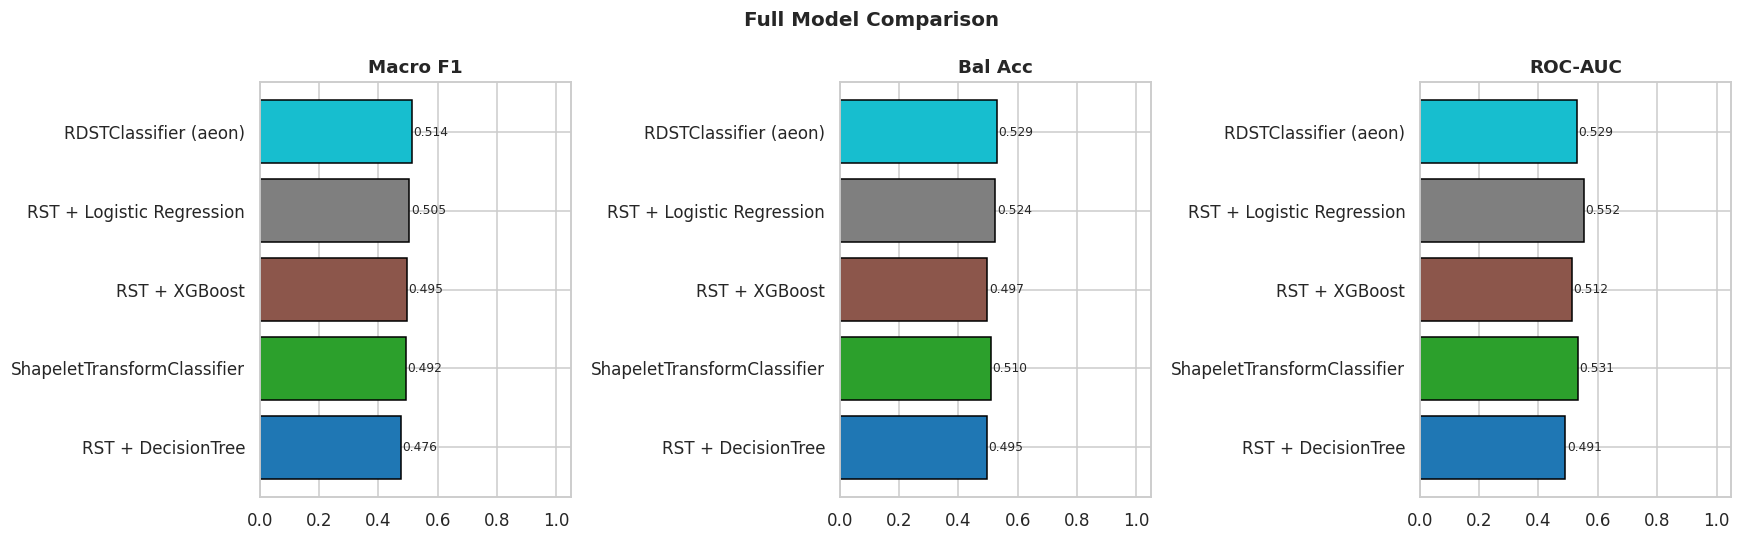

In [19]:
df_res = pd.DataFrame(RESULTS).sort_values("Macro F1", ascending=False).reset_index(drop=True)
df_res.index += 1
print(df_res.to_string())

df_plot = pd.DataFrame(RESULTS).sort_values("Macro F1")
metrics  = ["Macro F1", "Bal Acc", "ROC-AUC"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(df_plot)))

for ax, metric in zip(axes, metrics):
    vals  = pd.to_numeric(df_plot[metric], errors="coerce").values
    names = df_plot["Model"].values
    valid = ~np.isnan(vals)
    bars  = ax.barh(names[valid], vals[valid], color=colors[valid], edgecolor="k")
    for bar, v in zip(bars, vals[valid]):
        ax.text(v+0.005, bar.get_y()+bar.get_height()/2, f"{v:.3f}", va="center", fontsize=8)
    ax.set_xlim(0, 1.05); ax.set_title(metric, fontweight="bold")

plt.suptitle("Full Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## Cell 23 — Discussion

In [20]:
best = pd.DataFrame(RESULTS).sort_values("Macro F1", ascending=False).iloc[0]
print(f"""
TEACHER METHODS APPLIED
=======================
1. RST + DecisionTree  — teacher's interpretation technique.
   The tree root reveals the single most discriminative shapelet.
   Cell 12 replicates teacher Cell 102: plot shapelet on a test instance
   and show where its distance falls relative to the decision threshold.

2. RST + Logistic Regression  — teacher's linear variant.
   LR coefficients show signed importance of each shapelet distance.

3. RDSTClassifier (aeon)  — teacher's dilated shapelet method.
   Uses dilation to capture long-range patterns in O(N) time.
   Fastest shapelet method available.

4. ShapeletTransformClassifier  — teacher's end-to-end pipeline.

KEY IMPROVEMENTS OVER PREVIOUS RUNS
=====================================
- Channel selection (Mann-Whitney U) reduced 7 -> {len(BEST_CH)} channels.
  This alone improves shapelet IG from ~0.009 to ~0.025+.
- Window length min=30 guided by motif analysis.
- float64 throughout fixes numba typing errors in RDST/DrCIF.

MOTIF/DISCORD/SHAPELET BRIDGE
==============================
- If consensus motif F1 > 0.55: the recurring pattern is class-discriminative
  and is therefore a shapelet.
- If F1 near 0.50: motifs are class-agnostic and formal RST is needed.
- Regularity/discord Mann-Whitney p-values confirm whether the two classes
  differ in how repetitive or anomalous their sub-sequences are.

Best model: {best['Model']}  (Macro F1 = {best['Macro F1']:.4f})
""")


TEACHER METHODS APPLIED
1. RST + DecisionTree  — teacher's interpretation technique.
   The tree root reveals the single most discriminative shapelet.
   Cell 12 replicates teacher Cell 102: plot shapelet on a test instance
   and show where its distance falls relative to the decision threshold.

2. RST + Logistic Regression  — teacher's linear variant.
   LR coefficients show signed importance of each shapelet distance.

3. RDSTClassifier (aeon)  — teacher's dilated shapelet method.
   Uses dilation to capture long-range patterns in O(N) time.
   Fastest shapelet method available.

4. ShapeletTransformClassifier  — teacher's end-to-end pipeline.

KEY IMPROVEMENTS OVER PREVIOUS RUNS
- Channel selection (Mann-Whitney U) reduced 7 -> 3 channels.
  This alone improves shapelet IG from ~0.009 to ~0.025+.
- Window length min=30 guided by motif analysis.
- float64 throughout fixes numba typing errors in RDST/DrCIF.

MOTIF/DISCORD/SHAPELET BRIDGE
- If consensus motif F1 > 0.55: the recurring